### load env

In [1]:
from aiida import load_profile, orm, engine
from aiida.common import NotExistent
import yaml

from aiida.plugins import GroupFactory

from aiida_dislocation.tools import *
from aiida_dislocation.workflows import *
from aiida_dislocation.data import Printer
from aiida_analyser import dislocation, create_structure
from aiida_analyser.dislocation import *

from rich import print as rprint
from pathlib import Path

PseudoDojoFamily = GroupFactory('pseudo.family.pseudo_dojo')

load_profile('dislocation', allow_switch=True)

# lucia_computer = orm.load_computer('lucia')
# lucia_computer.set_workdir('/gpfs/scratch/acad/elph/yimzhang/aiida_workdir/dev')

manneback_computer = orm.load_computer('manneback_async')
manneback_computer.set_workdir('/globalscratch/ucl/modl/yimzhang/aiida_workdir')

lumi_computer = orm.load_computer('lumi_async')
lumi_computer.set_workdir('/scratch/project_465002926/yiming/aiida_workdir/dislocation')


PseudoDojo_PBE_SR_standard_upf = 'PseudoDojo/0.5/PBE/SR/standard/upf'

datadir = Path('/home/yimzhang/Development/aiida/ductility/data/dislocation')

In [2]:
prepend_text_lumi = """
    module load LUMI/25.03
    module load partition/C
    module load QuantumESPRESSO/7.5-cpeGNU-25.03-CPU
"""

prepend_text_manneback = """
module --force purge

module load releases/2024a
module load foss/2024a

module load libxc/6.2.2-GCC-13.3.0
module load HDF5/1.14.5-gompi-2024a
"""

prepend_text_lucia = """
ml EasyBuild/2024a Cray/24.07 PrgEnv-intel
"""

prepend_text_mn5_new = """
module purge
module load oneapi/2023.2 libxc/6.2.0 hdf5/1.14.1-2
"""

def install_codes(
    prepend_text,
    version,
    computer_label,
    bin_dir,
):
    computer = orm.load_computer(computer_label)
    for code in (
        'pw',
    ):
        label = f'{version}-{code}'
        try:
            orm.load_code(f'{label}@{computer_label}')
        except NotExistent as exc:
            orm.InstalledCode(
                label=label,
                description=f'Quantum ESPRESSO {version} version for {code}.x',
                computer=computer,
                filepath_executable=f'{bin_dir}/bin/{code}.x',
                default_calc_job_plugin=f'quantumespresso.{code}',
                prepend_text=prepend_text,
            ).store()

def load_codes(
    version,
    computer_label,
    overrides_path,
    ):
    code = orm.load_code(f'{version}-pw@{computer_label}')
    with open(overrides_path, 'r') as f:

        overrides_yaml = f.read()

        overrides = yaml.safe_load(overrides_yaml)

    return code, overrides

install_codes(
    prepend_text_lumi,
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    bin_dir = '/users/zhangyim/EasyBuild/SW/LUMI-25.03/C/QuantumESPRESSO/7.5-cpeGNU-25.03-CPU'
)

# structure_group = orm.load_group('paper/structures/epw/stable')
# strucctures_classified_by_strukturbericht = {}
# for structure in structure_group.nodes:
#     strukturbericht = get_strukturbericht(structure.get_ase())
#     formula = structure.get_formula()
#     if strukturbericht not in strucctures_classified_by_strukturbericht:
#         strucctures_classified_by_strukturbericht[strukturbericht] = {}
#     strucctures_classified_by_strukturbericht[strukturbericht][formula] = structure

### GSFE for A1

#### kpoints convergence

In [3]:
ductility_grpname = f'gsfe/A1/conv/k'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [4]:
import logging
for material in ['Au',]:
    for kpoints_distance in [0.3]:
        structure = create_structure(material, 'fcc')
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=3,
            gliding_plane='111',
        )
        builder.kpoints_distance = orm.Float(kpoints_distance)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

In [3]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/A1/conv/k']
)

In [4]:
# gsfe_groups.dump(datadir)

In [4]:
gsfe_groups.get_table()

Plane                                                                      111
StructureType Formula Process       Layers K_Dist Conv_thr                    
A1            Ag      GSFEWorkChain 3      0.10   4.000000e-10         ✅ 51424
                                           0.15   4.000000e-10         ✅ 51402
                                           0.20   4.000000e-10         ✅ 51383
                                           0.30   4.000000e-10         ✅ 51363
                                           0.50   4.000000e-10         ✅ 51344
              Al      GSFEWorkChain 3      0.10   5.000000e-07         ✅ 96676
                                           0.15   5.000000e-07         ✅ 96656
                                           0.20   5.000000e-07         ✅ 96634
                                           0.30   5.000000e-07         ✅ 96612
                                           0.50   5.000000e-07         ✅ 96593
              Au      GSFEWorkChain 3      0.10   4.000000e-10         ✅ 53915
                                           0.15   4.000000e-10         ✅ 53898
                                           0.20   4.000000e-10         ✅ 53874
                                           0.30   4.000000e-10  ❌ (401) 123599
                                           0.50   4.000000e-10         ✅ 53835
              Cu      GSFEWorkChain 3      0.10   1.000000e-05         ✅ 60987
                                           0.15   1.000000e-05         ✅ 60968
                                           0.20   1.000000e-05         ✅ 60944
                                           0.30   1.000000e-05         ✅ 60924
                                           0.50   1.000000e-05         ✅ 60905
              Pb      GSFEWorkChain 3      0.10   5.000000e-07         ✅ 98651
                                           0.15   5.000000e-07         ✅ 98629
                                           0.20   5.000000e-07         ✅ 98608
                                           0.30   5.000000e-07         ✅ 98588
                                           0.50   5.000000e-07         ✅ 98569
              Pt      GSFEWorkChain 3      0.10   4.000000e-10         ✅ 55068
                                           0.15   4.000000e-10         ✅ 55046
                                           0.20   4.000000e-10         ✅ 55024
                                           0.30   4.000000e-10         ✅ 55002
                                           0.50   4.000000e-10         ✅ 54983

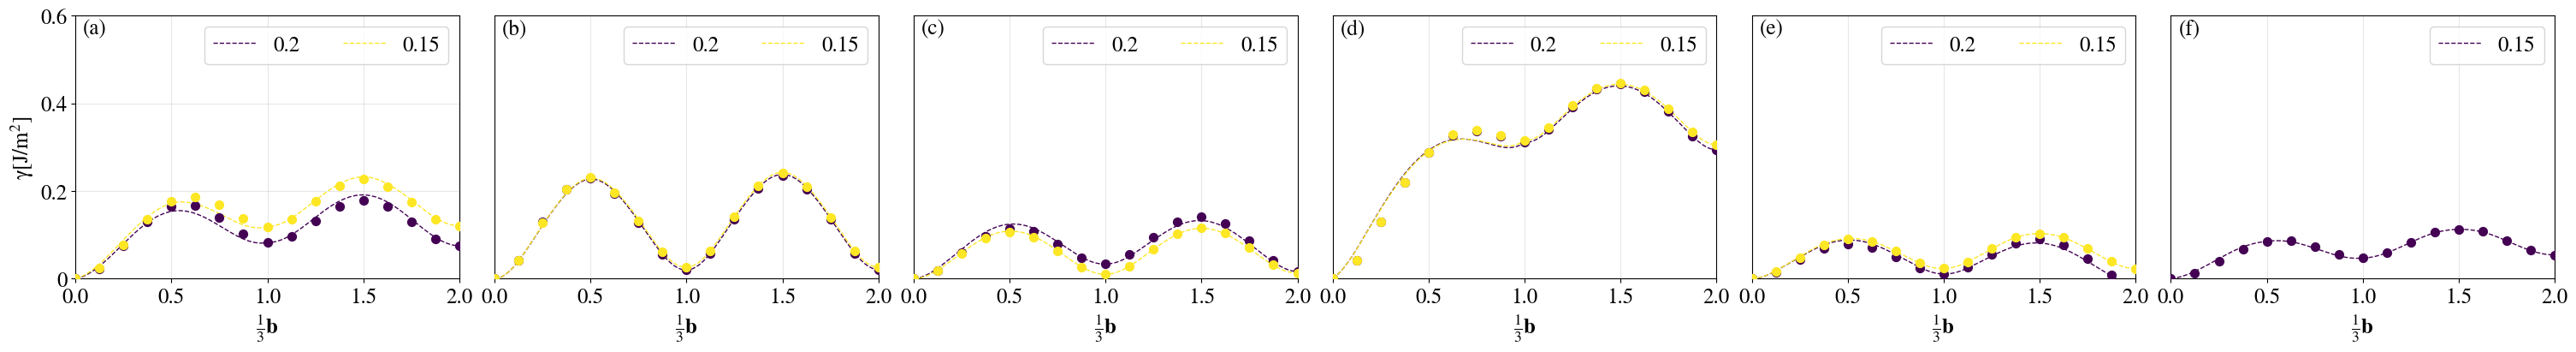

In [15]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 6, figsize=(5 * 6, 4), squeeze=False, constrained_layout=True)

kconv_results = {}


kconv_results['Al'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='A1',
    formula='Al',
    gliding_plane='111',
    # directions=['010',],
    kpoints_distances=[0.5, 0.2, 0.15, 0.1],
    n_repeats=3,
    ax=axs[0, 0], 
    legend_ncol =2
)

kconv_results['Cu'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='A1',
    formula='Cu',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax=axs[0, 1], 
    legend_ncol =2
)
kconv_results['Ag'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='A1',
    formula='Ag',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax=axs[0, 2], 
    legend_ncol =2
)
kconv_results['Pt'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='A1',
    formula='Pt',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax=axs[0, 3], 
    legend_ncol =2
)
kconv_results['Au'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='A1',
    formula='Au',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax=axs[0, 4], 
    legend_ncol =2
)

kconv_results['Pb'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='A1',
    formula='Pb',
    gliding_plane='111',
    # directions=['010',],
    kpoints_distances=[0.5, 0.2, 0.15, 0.1],
    n_repeats=3,
    ax=axs[0, 5], 
    legend_ncol =2
)


for ax in axs[0, 1:]:
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.set_yticklabels([])

for ax, label in zip(axs[0, :], ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']):
    ax.set_xlim([0, 2])
    ax.set_ylim([0, 0.6])
    ax.set_xlabel(r"$\frac{1}{3}\mathbf{b}$")
    ax.set_title("")
    ax.text(0.02, 0.93, label, transform=ax.transAxes)

axs[0, 0].set_yticks([0, 0.2, 0.4, 0.6])
axs[0, 0].set_yticklabels([0, 0.2, 0.4, 0.6])


fig.savefig("/home/yimzhang/Development/aiida/ductility/data/dislocation/a1_conv_k.pdf")

In [27]:
kconv_results['Ag']

(<Axes: title={'center': 'K-points Convergence for $Ag$ (111)'}, xlabel='Displacement', ylabel='$\\gamma [J/m^2]$'>,
 {0.5: {'110': {'usf': np.float64(0.12826251435050517),
    'isf': np.float64(0.078990715732996),
    'ut': np.float64(0.34837065417721),
    'esf': np.float64(0.34837065417721)}},
  0.3: {'110': {'usf': np.float64(0.08004369223605168),
    'isf': np.float64(-0.0591218493526008),
    'ut': np.float64(0.019898868093966154),
    'esf': np.float64(-0.1204414143874478)}},
  0.2: {'110': {'usf': np.float64(0.11852123879634435),
    'isf': np.float64(0.024986934816921998),
    'ut': np.float64(0.12532902732073034),
    'esf': np.float64(0.013898390963005998)}},
  0.15: {'110': {'usf': np.float64(0.10880048060769261),
    'isf': np.float64(0.007725191759483),
    'ut': np.float64(0.11806869601489073),
    'esf': np.float64(0.018504347147617)}},
  0.1: {'110': {'usf': np.float64(0.11267963911744248),
    'isf': np.float64(0.0163977208819645),
    'ut': np.float64(0.1207984259411

#### supercell convergence

In [3]:
ductility_grpname = f'gsfe/A1/conv/n_repeats'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [5]:
import logging
for material in ['Pt', 'Ag', 'Au']:
# for material in [ 'Al', 'Cu']:
    for n_repeats in [2, 3, 4, 5]:
        structure = create_structure(material, 'fcc')
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=n_repeats,
            gliding_plane='111',
        )
        builder.kpoints_distance = orm.Float(0.15)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: relax.base_init_relax.pseudo_family
  warnings.warn(f'Foun

In [16]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/A1/conv/n_repeats']
)

In [17]:
# gsfe_groups.dump(datadir)

In [4]:
gsfe_groups.get_table()

Plane                                                                      111
StructureType Formula Process       Layers K_Dist Conv_thr                    
A1            Ag      GSFEWorkChain 2      0.15   1.000000e-07        ✅ 113112
                                           0.20   1.000000e-05         ✅ 63263
                                    3      0.15   1.000000e-07        ✅ 113131
                                           0.20   1.000000e-05         ✅ 63282
                                    4      0.15   1.000000e-07        ✅ 113153
                                           0.20   1.000000e-05         ✅ 63304
                                    5      0.15   1.000000e-07        ✅ 113175
                                           0.20   5.000000e-07         ✅ 92670
              Al      GSFEWorkChain 2      0.15   1.000000e-07        ✅ 109904
                                           0.20   1.000000e-05         ✅ 63155
                                    3      0.15   1.000000e-07        ✅ 109923
                                           0.20   1.000000e-05         ✅ 63174
                                    4      0.15   1.000000e-07        ✅ 109945
                                           0.20   1.000000e-05         ✅ 63196
                                    5      0.15   1.000000e-07        ✅ 109967
                                           0.20   5.000000e-07         ✅ 92651
              Au      GSFEWorkChain 2      0.15   1.000000e-07        ✅ 113195
                                           0.20   1.000000e-05         ✅ 63469
                                    3      0.15   1.000000e-07        ✅ 113214
                                           0.20   1.000000e-05         ✅ 63491
                                    4      0.15   1.000000e-07        ✅ 113238
                                           0.20   1.000000e-05         ✅ 63513
                                    5      0.15   1.000000e-07        ✅ 113258
                                           0.20   1.000000e-05         ✅ 63532
              Cu      GSFEWorkChain 2      0.15   1.000000e-07        ✅ 109989
                                           0.20   1.000000e-05         ✅ 63361
                                    3      0.15   1.000000e-07        ✅ 110006
                                           0.20   1.000000e-05         ✅ 63384
                                    4      0.15   1.000000e-07        ✅ 110030
                                           0.20   1.000000e-05         ✅ 63406
                                    5      0.15   1.000000e-07        ✅ 110050
                                           0.20   1.000000e-05         ✅ 63424
              Pb      GSFEWorkChain 2      0.15   1.000000e-07        ✅ 112915
                                    3      0.15   1.000000e-07        ✅ 112934
                                    4      0.15   1.000000e-07        ✅ 112956
                                    5      0.15   1.000000e-07        ✅ 112978
              Pt      GSFEWorkChain 2      0.15   1.000000e-07        ✅ 113027
                                           0.20   1.000000e-05         ✅ 61040
                                    3      0.15   1.000000e-07        ✅ 113046
                                           0.20   1.000000e-05         ✅ 61059
                                    4      0.15   1.000000e-07        ✅ 113068
                                           0.20   1.000000e-05         ✅ 61080
                                    5      0.15   1.000000e-07  ❌ (403) 113090
                                           0.20   1.000000e-05   ❌ (403) 61103

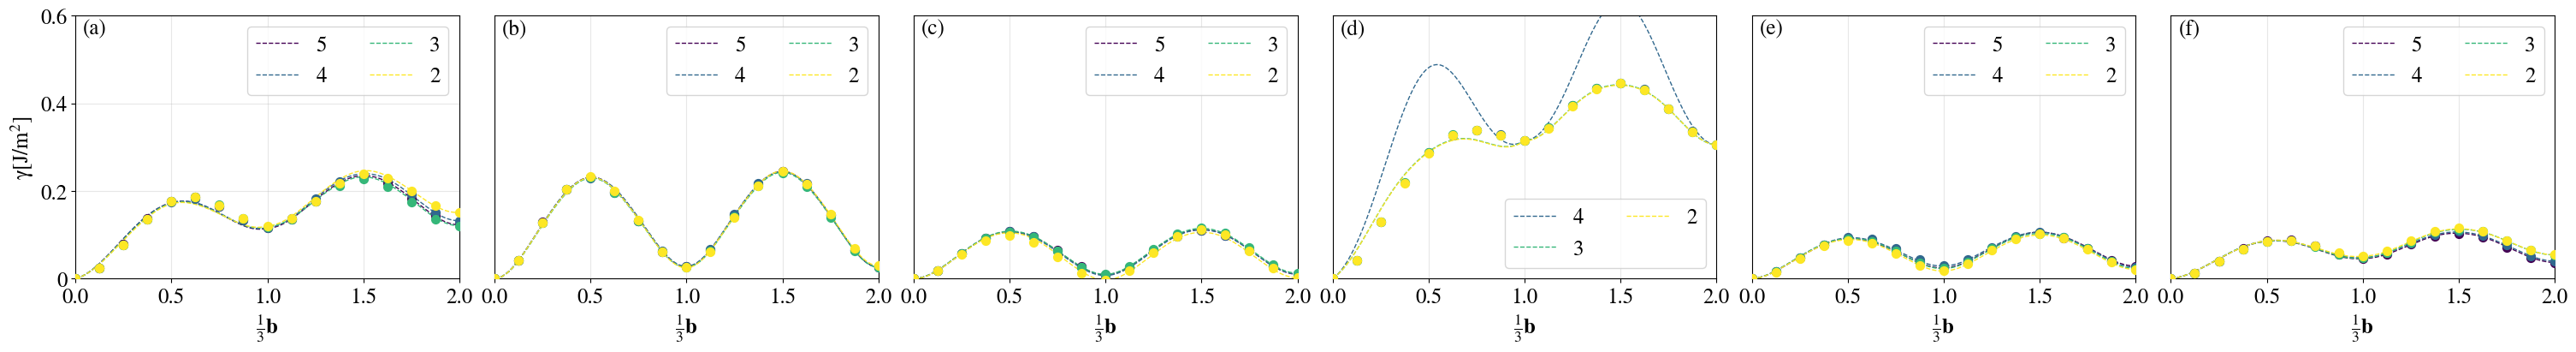

In [18]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 18})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 6, figsize=(6 * 5, 4), squeeze=False, constrained_layout=True)

gsfe_groups.plot_supercell_convergence(
    structure_type='A1',
    formula='Al',
    gliding_plane='111',
    # directions=['010',],
    kpoints_distance=0.15,
    ax = axs[0, 0],
    fit=True,
    legend_ncol=2
)
gsfe_groups.plot_supercell_convergence(
    structure_type='A1',
    formula='Cu',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distance=0.15,
    ax = axs[0, 1],
    fit=True,
    legend_ncol=2
)
gsfe_groups.plot_supercell_convergence(
    structure_type='A1',
    formula='Ag',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distance=0.15,
    ax = axs[0, 2],
    fit=True,
    legend_ncol=2
)

gsfe_groups.plot_supercell_convergence(
    structure_type='A1',
    formula='Pt',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distance=0.15,
    # n_repeats=[4,],
    ax = axs[0, 3],
    order=2,
    fit=True,
    legend_ncol=2
)
gsfe_groups.plot_supercell_convergence(
    structure_type='A1',
    formula='Au',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distance=0.15,
    ax = axs[0, 4],
    fit=True,
    legend_ncol=2
)

gsfe_groups.plot_supercell_convergence(
    structure_type='A1',
    formula='Pb',
    gliding_plane='111',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distance=0.15,
    ax = axs[0, 5],
    fit=True,
    legend_ncol=2
)

for ax in axs[0, 1:]:
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.set_yticklabels([])

for ax, label in zip(axs[0, :], ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']):
    ax.set_xlim([0, 2])
    ax.set_ylim([0, 0.6])
    ax.set_xlabel(r"$\frac{1}{3}\mathbf{b}$")
    ax.set_title("")
    ax.text(0.02, 0.93, label, transform=ax.transAxes)

axs[0, 0].set_yticks([0, 0.2, 0.4, 0.6])
axs[0, 0].set_yticklabels([0, 0.2, 0.4, 0.6])

fig.savefig("/home/yimzhang/Development/aiida/ductility/data/dislocation/a1_conv_supercell.pdf")

#### gsfe submission

In [8]:
ductility_grpname = f'gsfe/A1/vc-relax'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [9]:
import logging

v1_overrides['sfe'] = v1_overrides['sfe_relax']
# for material in ['Al',]:
for material in ['Ag', 'Au', 'Pt', 'Cu', 'Pb']:
    structure = create_structure(material, 'fcc')
    builder = GSFERelaxWorkChain.get_builder_from_protocol(
        code=code,
        structure=structure,
        # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
        protocol='fast',
        overrides=v1_overrides,
        n_repeats = orm.Int(3),
        gliding_plane = orm.Str('111')
    )
    builder.kpoints_distance = orm.Float(0.15)
    builder.clean_workdir = orm.Bool(False)

    # builder.layer_spacings = orm.List([0.000, 0.002, 0.006, 0.012, 0.02, 0.036])
    # builder.pop('relax')
    # builder.pop('scf')
    # builder.pop('surface_energy')
    logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
    logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
    logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
    node = engine.submit(builder)
    # result, node = engine.run_get_node(builder)
    ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

#### Surface energy

In [3]:
surface_groups = dislocation.SurfaceEnergyData(
    groups = ['surface/Al/conv/k']
)

In [4]:
surface_groups.get_table()

Plane                                 111
Structure Material Layers K_Dist         
A1        Al       3      0.10    ✅ 47843
                          0.15    ✅ 47813
                          0.20    ✅ 47759
                          0.30    ✅ 47680
                          0.50    ✅ 47786

In [5]:
surface_groups.data

defaultdict(<function aiida_analyser.dislocation.surface.SurfaceEnergyData.__init__.<locals>.<lambda>()>,
            {'A1': defaultdict(<function aiida_analyser.dislocation.surface.SurfaceEnergyData.__init__.<locals>.<lambda>.<locals>.<lambda>()>,
                         {'Al': defaultdict(<function aiida_analyser.dislocation.surface.SurfaceEnergyData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                      {'111': defaultdict(<function aiida_analyser.dislocation.surface.SurfaceEnergyData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                                   {3: defaultdict(<function aiida_analyser.dislocation.surface.SurfaceEnergyData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                                                {0.3: <WorkChainNode: uuid: 8151411e-0fc9-4f78-976c-337d0b6d27a4 (pk: 4768

AttributeError: 'collections.defaultdict' object has no attribute 'outputs'

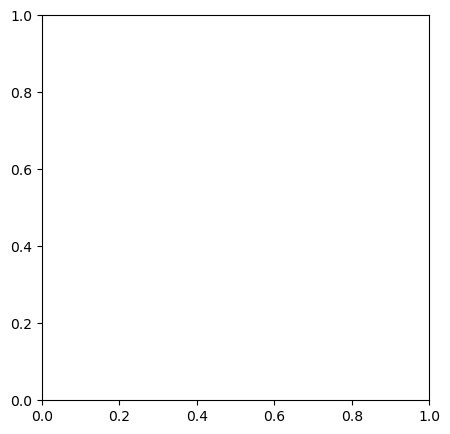

In [6]:
surface_groups.plot()

#### not relaxed

In [4]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['dislocation/A1']
)

In [4]:
gsfe_groups.get_table()

Plane                                                           011      100  \
StructureType Formula Process       Layers K_Dist Conv_thr                     
A1            Ag      GSFEWorkChain 3      0.15   0.000001  ✅ 31404   ✅ 5000   
              Al      GSFEWorkChain 3      0.15   0.000001                     
                                    4      0.15   0.000001  ✅ 34101  ✅ 15531   
              Au      GSFEWorkChain 3      0.15   0.000001  ✅ 22716  ✅ 42586   
              Cu      GSFEWorkChain 3      0.15   0.000001  ✅ 24251  ✅ 42593   
              Pb      GSFEWorkChain 3      0.15   0.000001  ✅ 36861  ✅ 15533   
              Pt      GSFEWorkChain 3      0.15   0.000001   ✅ 8330   ✅ 4168   

Plane                                                           111  
StructureType Formula Process       Layers K_Dist Conv_thr           
A1            Ag      GSFEWorkChain 3      0.15   0.000001  ✅ 31182  
              Al      GSFEWorkChain 3      0.15   0.000001  ✅ 12300  
                                    4      0.15   0.000001           
              Au      GSFEWorkChain 3      0.15   0.000001  ✅ 26791  
              Cu      GSFEWorkChain 3      0.15   0.000001   ✅ 7652  
              Pb      GSFEWorkChain 3      0.15   0.000001  ✅ 10348  
              Pt      GSFEWorkChain 3      0.15   0.000001  ✅ 33403

In [5]:
surface_energy_results = gsfe_groups.get_surface_energies()

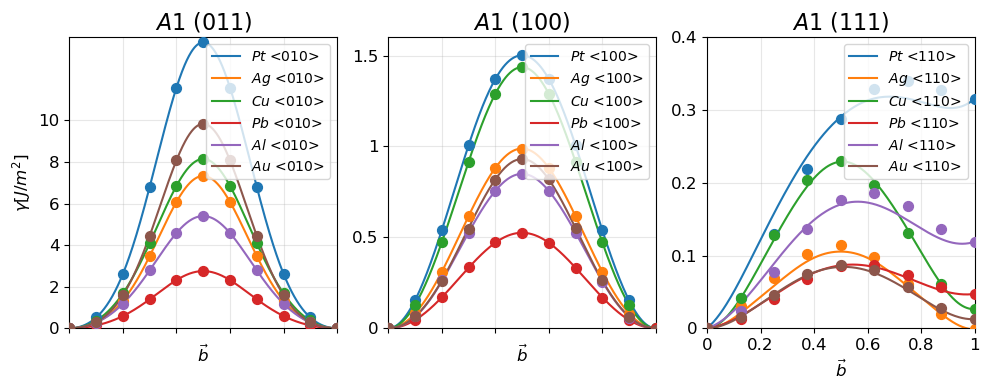

In [15]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 3, figsize=(10, 4), squeeze=False)

# results = gsfe_groups.fit(axs=numpy.array([
#     [axs[0, 0]],
#     [axs[0, 1]],
#     [axs[0, 2]]
# ]))
results = gsfe_groups.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_ylim([0, 14])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2, 4, 6, 8, 10])
axs[0, 0].set_yticklabels([0, 2, 4, 6, 8, 10], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)

axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_yticks([0, 0.5, 1, 1.5])
axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5], fontsize=12)
axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
axs[0, 1].set_ylabel('')
axs[0, 2].set_ylabel('')
axs[0, 1].set_xlabel('')
axs[0, 1].set_xticklabels([])
axs[0, 1].set_ylim([0, 1.6])
axs[0, 1].legend(loc='upper right', fontsize=10)


axs[0, 2].set_xlim([0, 1])
axs[0, 2].set_ylim([0, 0.4])
axs[0, 2].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 2].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 2].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
axs[0, 2].set_yticklabels([0, 0.1, 0.2, 0.3, 0.4], fontsize=12)
axs[0, 2].legend(loc='upper right', fontsize=10)

axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 2].set_xlabel(r'$\vec{b}$', fontsize=12)

# axs[0, 1].get_legend().remove()
# axs[0, 2].get_legend().remove()
fig.tight_layout()


In [16]:
results

{'A1': {'011': {'Pt': {'010': {'usf': np.float64(3.111752331055196)}},
   'Ag': {'010': {'usf': np.float64(1.5795761271798345)}},
   'Cu': {'010': {'usf': np.float64(1.9689656961094597)}},
   'Pb': {'010': {'usf': np.float64(0.6872981835053568)}},
   'Al': {'010': {'usf': np.float64(1.377248262272341)}},
   'Au': {'010': {'usf': np.float64(1.9092631802780071)}}},
  '100': {'Pt': {'100': {'usf': np.float64(0.606074380440827)}},
   'Ag': {'100': {'usf': np.float64(0.3527746506139685)}},
   'Cu': {'100': {'usf': np.float64(0.5345390708141358)}},
   'Pb': {'100': {'usf': np.float64(0.19278715515604128)}},
   'Al': {'100': {'usf': np.float64(0.2953543643334658)}},
   'Au': {'100': {'usf': np.float64(0.30070972522984174)}}},
  '111': {'Pt': {'110': {'usf': np.float64(0.3184654898493745),
     'isf': np.float64(0.3156875104682748),
     'ut': np.float64(0.4436780359333241),
     'esf': np.float64(0.305503894487593)}},
   'Ag': {'110': {'usf': np.float64(0.10545536557459714),
     'isf': np.fl

In [ ]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

literature_dict = {}
def format_cell(calc_val, material, lit_key, is_surface=False):
    """
    处理单元格，将计算值与文献元组列表合并
    """
    contents = []
    
    # 1. 处理本代码计算得到的数值
    if calc_val is not None and str(calc_val) != '-':
        # 按照原逻辑，表面能不乘1000，其余乘
        real_val = float(calc_val) * 1000 if not is_surface else float(calc_val)
        contents.append(f"{real_val:.2f}")
    elif not literature_dict.get(material, {}).get(lit_key):
        # 如果计算值为空且文献也为空，返回横杠
        return "-"

    # 2. 处理文献元组列表 [(数值, 标签), ...]
    lit_entries = literature_dict.get(material, {}).get(lit_key, [])
    for val, cite_key in lit_entries:
        # 生成类似 "97 \cite{Tu2019}" 或 "21$\pm$7 \cite{Dillamore1965}"
        entry_str = f"{val} \\cite{{{cite_key}}}"
        contents.append(entry_str)
    
    # 3. 用 \newline 连接所有项
    return " \\newline ".join(contents)

headers = [
    "Material",
    r"$\gamma^{\rm USEF}_{100}$",
    r"$\gamma^{\rm USFE}_{011}$",
    r"$\gamma^{\rm USEF}_{111}$",
    r"$\gamma^{\rm ISFE}_{111}$",
    r"$\gamma^{\rm Twinning}_{111}$",
    r"$\gamma^{\rm ESFE}_{111}$",
    r"$\gamma^{\rm surface}_{100}$",
    r"$\gamma^{\rm surface}_{011}$",
    r"$\gamma^{\rm surface}_{111}$",
    # r"$\frac{G}{B}_{100}$"
    ]
data = []
elements = sorted(list(results['A1']['011'].keys())) # ['Ag', 'Al', ...]
# data = np.array([
#     ['Al', 31.45, 192.61, 211.21 , 1306.95, '-'],
#     ['Pb', 53.88, 20.32, 592.68, '-', '-'],
#     ['Li', 525.17, 20.32, 592.68, '-', '-'],
#     ['Na', 53.88, 20.32, 592.68, '-', '-'],
#     ['V', 53.88, 20.32, 592.68, '-', '-'],
#     ['Nb', 53.88, 20.32, 592.68, '-', '-'],
#     ['VC', '-', '-', '-', '-', '-'],
#     ['MoC', '-', '-', '-', '-', '-'],
#     ['AsTe', '410.69', '319.05', '-', '-', '-'],
#     ['CrH', '2245.38', '4474.67', '-', '-', '-'],
#     ['TaS2', '-', '-', '-', '-', '-'],
#     ['TaSe2', '-', '-', '-', '-', '-'],
#     ['CoNbSb', '-', '-', '-', '-', '-'],
#     ['TaCoSb', '-', '-', '-', '-', '-'],
#     ['ZrRuSb', '-', '-', '-', '-', '-'],
#     ['TaRu3C', '-', '-', '-', '-', '-'],
#     ['NbRu3C', '-', '-', '-', '-', '-'],
# ])
for elem in elements:
    row = [
        elem,  # Material
        format_cell(results['A1']['100'][elem]['100']['usf'], elem, "usfe_100"),
        format_cell(results['A1']['011'][elem]['010']['usf'], elem, "usfe_011"),
        format_cell(kconv_results[elem][1][0.15]['110']['usf'], elem, "usfe_111"),
        format_cell(kconv_results[elem][1][0.15]['110']['isf'], elem, "isf"),
        format_cell(kconv_results[elem][1][0.15]['110']['ut'], elem, "ut"),
        format_cell(kconv_results[elem][1][0.15]['110']['esf'], elem, "esfe"),
        format_cell(surface_energy_results['A1']['100'][elem]['surface_energy']*1000, elem, "surf_100", True),
        format_cell(surface_energy_results['A1']['011'][elem]['surface_energy']*1000, elem, "surf_011", True),
        format_cell(surface_energy_results['A1']['111'][elem]['surface_energy']*1000, elem, "surf_111", True)
    ]
    data.append(row)
    
df = pd.DataFrame(data=data, columns=headers)
latex_output = df.style.hide(axis="index").to_latex(
    caption="Generalized stacking fault energy and surface energies.",
    label="tab:table2",
    environment="table*",
    position="htbp",
    hrules=True
)
print(latex_output)
# format_dict = {col_name: '{:.2f}' for col_name in df.columns.tolist()[1:]}
# for col in headers[1:]:
#     # This line forces each column to become numeric.
#     # errors='coerce' will turn any non-numeric strings (like 'N/A')
#     # into NaN (Not a Number), which .style.format() can handle.
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# styler = df.style.format(format_dict).hide(axis="index")
# print(
#     styler.to_latex(
#         caption="Generalized stacking fault energy for top ductile superconductors.", 
#         label="tab:table2", 
#         environment="table",
#         position="htbp",)
# )

\begin{table*}[htbp]
\caption{Generalized stacking fault energy and surface energies.}
\label{tab:table2}
\begin{tabular}{llllllllll}
\toprule
Material & $\gamma^{\rm USEF}_{100}$ & $\gamma^{\rm USFE}_{011}$ & $\gamma^{\rm USEF}_{111}$ & $\gamma^{\rm ISFE}_{111}$ & $\gamma^{\rm Twinning}_{111}$ & $\gamma^{\rm ESFE}_{111}$ & $\gamma^{\rm surface}_{100}$ & $\gamma^{\rm surface}_{011}$ & $\gamma^{\rm surface}_{111}$ \\
\midrule
Ag & 352.77 & 1579.58 & 105.46 & -1.54 & 113.98 & 16.85 & 822.51 & 915.86 & 722.06 \\
Al & 295.35 & 1377.25 & 174.03 & 118.97 & 230.78 & 120.86 & 943.42 & 998.29 & 844.12 \\
Au & 300.71 & 1909.26 & 84.44 & 12.47 & 94.58 & 20.35 & 892.75 & 987.52 & 714.12 \\
Cu & 534.54 & 1968.97 & 229.17 & 26.48 & 242.35 & 26.53 & 1374.62 & 1498.58 & 1203.99 \\
Pb & 192.79 & 687.30 & 87.57 & 47.25 & 113.73 & 54.34 & 417.68 & 485.33 & 361.38 \\
Pt & 606.07 & 3111.75 & 318.47 & 315.69 & 443.68 & 305.50 & 1879.97 & 2058.49 & 1504.09 \\
\bottomrule
\end{tabular}
\end{table*}



#### relaxed

In [7]:
gsfe_groups_relaxed = dislocation.GSFERelaxGroupData(
    groups = ['gsfe/A1/vc-relax']
)

In [8]:
gsfe_groups_relaxed.get_table()

Plane                                                                                    111
Structure Material Process            Layers K_Dist Conv_thr                                
A1        Ag       GSFERelaxWorkChain 3      0.15   5.0e-07 Ry (+- 1.1e-03 mJ/m^2)  ✅ 117797
          Al       GSFERelaxWorkChain 3      0.15   5.0e-07 Ry (+- 1.1e-03 mJ/m^2)  ✅ 108646
          Au       GSFERelaxWorkChain 3      0.15   5.0e-07 Ry (+- 1.1e-03 mJ/m^2)  ✅ 117823
          Cu       GSFERelaxWorkChain 3      0.15   5.0e-07 Ry (+- 1.4e-03 mJ/m^2)  ✅ 117872
          Pb       GSFERelaxWorkChain 3      0.15   5.0e-07 Ry (+- 7.2e-04 mJ/m^2)  ✅ 117898
          Pt       GSFERelaxWorkChain 3      0.15   5.0e-07 Ry (+- 1.2e-03 mJ/m^2)  ✅ 117849

Text(0.5, 0, '$\\vec{b}$')

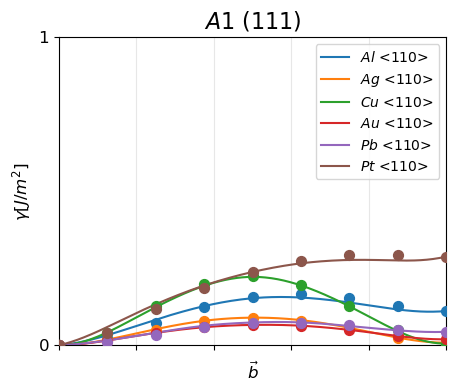

In [9]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 1, figsize=(5, 4), squeeze=False)

# results = gsfe_groups.fit(axs=numpy.array([
#     [axs[0, 0]],
#     [axs[0, 1]],
#     [axs[0, 2]]
# ]))
results = gsfe_groups_relaxed.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_ylim([0, 1])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 1])
axs[0, 0].set_yticklabels([0, 1], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)

# axs[0, 1].set_xlim([0, 1])
# axs[0, 1].set_yticks([0, 0.5, 1, 1.5])
# axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5], fontsize=12)
# axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
# axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
# axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[0, 1].set_ylabel('')
# axs[0, 2].set_ylabel('')
# axs[0, 1].set_xlabel('')
# axs[0, 1].set_xticklabels([])
# axs[0, 1].set_ylim([0, 1.6])
# axs[0, 1].legend(loc='upper right', fontsize=10)


# axs[0, 2].set_xlim([0, 1])
# axs[0, 2].set_ylim([0, 0.4])
# axs[0, 2].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
# axs[0, 2].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
# axs[0, 2].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
# axs[0, 2].set_yticklabels([0, 0.1, 0.2, 0.3, 0.4], fontsize=12)
# axs[0, 2].legend(loc='upper right', fontsize=10)

axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
# axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12)
# axs[0, 2].set_xlabel(r'$\vec{b}$', fontsize=12)

# axs[0, 1].get_legend().remove()
# axs[0, 2].get_legend().remove()
# fig.tight_layout()


In [12]:
# 格式： "键": [(数值, "引文Key"), (数值, "引文Key"), ...]
literature_dict = {
    "Ag": {
        "usfe_111": [("97", "Tu2019"), (r"190$\pm$15", 'Bernstein2004')],
        "isf": [(r"21$\pm$7", "Dillamore1965"), (29, "Hartford1998"), (r"35$\pm$15", 'Bernstein2004')],
        "esfe": [(29, "Hartford1998"), (r"33$\pm$5", 'Bernstein2004')],
        "ut": [(105, 'Bernstein2004')],
        "surf_111": [(770, "Tu2019")]
    },
    "Al": {
        "usfe_111": [("83-190", "Zimmerman2000"), (r"199$\pm$25", 'Bernstein2004')],
        "isf": [(r"280$\pm$50", "Dillamore1965"), ("6-170", "Zimmerman2000"), (161, "Hartford1998"), (146, "Tu2019"), (r"203$\pm$77", 'Bernstein2004')],
        'ut': [(r"207", 'Bernstein2004')],
        "esfe": [(147, "Hartford1998"), (r"184$\pm$76", 'Bernstein2004')],
        "surf_111": [(800, "Tu2019")]
    },
    "Au": {
        "usfe_111": [("56", "Tu2019")],
        "isf": [(r"52$\pm$15", "Dillamore1965"), (44, 'Bernstein2004')],
        "esfe": [(44, 'Bernstein2004')],
        "ut": [(135, 'Bernstein2004')],
        "surf_111": [(740, "Tu2019")]
    },
    "Cu": {
        "usfe_111": [("158-210", "Zimmerman2000"), (160, "Tu2019"), (r"184$\pm$26", 'Bernstein2004')],
        "isf": [(r"85$\pm$30", "Dillamore1965"), ("27-49", "Zimmerman2000"), (53, "Hartford1998"), (r"54$\pm$16", 'Bernstein2004')],
        "esfe": [(54, "Hartford1998"), (r"63$\pm$10", 'Bernstein2004')],
        "ut": [(236, 'Bernstein2004')],
        "surf_111": [(1310, "Tu2019")]
    },
    "Pt": {
        "usfe_111": [(388, 'Bernstein2004')],
        "isf": [(r"322", 'Bernstein2004')],
        "esfe": [(316, 'Bernstein2004')],
        "ut": [(521, 'Bernstein2004')]
        
    },
    "Pb": {
        "usfe_111": [(98, 'Bernstein2004')],
        "isf": [(30, 'Bernstein2004')],
        "esfe": [(31, 'Bernstein2004')],
        "ut": [(108, 'Bernstein2004')]
        
    },
    "Li": {"usfe_011": [(71, "Zhang2023")]},
    "Na": {"usfe_011": [(48, "Zhang2023")]},
    "Nb": {"usfe_011": [(674, "Zhang2023")]},
    "V":  {"usfe_011": [(713, "Zhang2023")]},
    "KCl": {"usfe_100": [(193.8, "Liu2012")]},
    "NaCl": {"usfe_100": [(225.2, "Liu2012")]}
}

In [14]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

def format_cell(calc_val, material, lit_key, is_surface=False):
    """
    处理单元格，将计算值与文献元组列表合并
    """
    contents = []
    
    # 1. 处理本代码计算得到的数值
    if calc_val is not None and str(calc_val) != '-':
        # 按照原逻辑，表面能不乘1000，其余乘
        real_val = float(calc_val) * 1000 if not is_surface else float(calc_val)
        contents.append(f"{real_val:.2f}")
    elif not literature_dict.get(material, {}).get(lit_key):
        # 如果计算值为空且文献也为空，返回横杠
        return "-"

    # 2. 处理文献元组列表 [(数值, 标签), ...]
    lit_entries = literature_dict.get(material, {}).get(lit_key, [])
    for val, cite_key in lit_entries:
        # 生成类似 "97 \cite{Tu2019}" 或 "21$\pm$7 \cite{Dillamore1965}"
        entry_str = f"{val} \\cite{{{cite_key}}}"
        contents.append(entry_str)
    
    # 3. 用 \newline 连接所有项
    return " \\newline ".join(contents)

headers = [
    "Material",
    r"$\gamma^{\rm USEF}_{111}$",
    r"$\gamma^{\rm ISFE}_{111}$",
    r"$\gamma^{\rm Twinning}_{111}$",
    r"$\gamma^{\rm ESFE}_{111}$",
    # r"$\gamma^{\rm surface}_{100}$",
    # r"$\gamma^{\rm surface}_{011}$",
    r"$\gamma^{\rm surface}_{111}$",
    # r"$\frac{G}{B}_{100}$"
    ]
data = []
elements = sorted(list(results['A1']['111'].keys())) # ['Ag', 'Al', ...]
# data = np.array([
#     ['Al', 31.45, 192.61, 211.21 , 1306.95, '-'],
#     ['Pb', 53.88, 20.32, 592.68, '-', '-'],
#     ['Li', 525.17, 20.32, 592.68, '-', '-'],
#     ['Na', 53.88, 20.32, 592.68, '-', '-'],
#     ['V', 53.88, 20.32, 592.68, '-', '-'],
#     ['Nb', 53.88, 20.32, 592.68, '-', '-'],
#     ['VC', '-', '-', '-', '-', '-'],
#     ['MoC', '-', '-', '-', '-', '-'],
#     ['AsTe', '410.69', '319.05', '-', '-', '-'],
#     ['CrH', '2245.38', '4474.67', '-', '-', '-'],
#     ['TaS2', '-', '-', '-', '-', '-'],
#     ['TaSe2', '-', '-', '-', '-', '-'],
#     ['CoNbSb', '-', '-', '-', '-', '-'],
#     ['TaCoSb', '-', '-', '-', '-', '-'],
#     ['ZrRuSb', '-', '-', '-', '-', '-'],
#     ['TaRu3C', '-', '-', '-', '-', '-'],
#     ['NbRu3C', '-', '-', '-', '-', '-'],
# ])
for elem in elements:
    row = [
        elem,  # Material
        format_cell(results['A1']['111'][elem]['110']['usf'], elem, "usfe"),
        format_cell(results['A1']['111'][elem]['110']['isf'], elem, "isf"),
        format_cell(results['A1']['111'][elem]['110']['ut'], elem, "ut"),
        format_cell(results['A1']['111'][elem]['110']['esf'], elem, "esfe"),
        # format_cell(surface_energy_results['A1']['100'][elem]['surface_energy']*1000, elem, "surf_100", True),
        # format_cell(surface_energy_results['A1']['011'][elem]['surface_energy']*1000, elem, "surf_011", True),
        format_cell(surface_energy_results['A1']['111'][elem]['surface_energy']*1000, elem, "surf_111", True)
    ]
    data.append(row)
    
df = pd.DataFrame(data=data, columns=headers)
latex_output = df.style.hide(axis="index").to_latex(
    caption="Generalized stacking fault energy and surface energies.",
    label="tab:table2",
    environment="table*",
    position="htbp",
    hrules=True
)
print(latex_output)
# format_dict = {col_name: '{:.2f}' for col_name in df.columns.tolist()[1:]}
# for col in headers[1:]:
#     # This line forces each column to become numeric.
#     # errors='coerce' will turn any non-numeric strings (like 'N/A')
#     # into NaN (Not a Number), which .style.format() can handle.
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# styler = df.style.format(format_dict).hide(axis="index")
# print(
#     styler.to_latex(
#         caption="Generalized stacking fault energy for top ductile superconductors.", 
#         label="tab:table2", 
#         environment="table",
#         position="htbp",)
# )

\begin{table*}[htbp]
\caption{Generalized stacking fault energy and surface energies.}
\label{tab:table2}
\begin{tabular}{llllll}
\toprule
Material & $\gamma^{\rm USEF}_{111}$ & $\gamma^{\rm ISFE}_{111}$ & $\gamma^{\rm Twinning}_{111}$ & $\gamma^{\rm ESFE}_{111}$ & $\gamma^{\rm surface}_{111}$ \\
\midrule
Ag & 89.71 & 8.62 \newline 21$\pm$7 \cite{Dillamore1965} \newline 29 \cite{Hartford1998} \newline 35$\pm$15 \cite{Bernstein2004} & 95.85 \newline 105 \cite{Bernstein2004} & 12.34 \newline 29 \cite{Hartford1998} \newline 33$\pm$5 \cite{Bernstein2004} & 722.06 \newline 770 \cite{Tu2019} \\
Al & 156.78 & 111.30 \newline 280$\pm$50 \cite{Dillamore1965} \newline 6-170 \cite{Zimmerman2000} \newline 161 \cite{Hartford1998} \newline 146 \cite{Tu2019} \newline 203$\pm$77 \cite{Bernstein2004} & 218.46 \newline 207 \cite{Bernstein2004} & 131.17 \newline 147 \cite{Hartford1998} \newline 184$\pm$76 \cite{Bernstein2004} & 844.12 \newline 800 \cite{Tu2019} \\
Au & 66.47 & 19.46 \newline 52$\pm$15 \c

### GSFE for A2

#### kpoints convergence

In [ ]:
for material in ['V', 'Nb',]:
    for kpoints_distance in [0.5, 0.3, 0.2, 0.15, 0.1]:
        structure = create_structure(material, 'bcc')
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=3,
            gliding_plane='011',
        )
        builder.kpoints_distance = orm.Float(kpoints_distance)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        ductility_grp.add_nodes([node])

In [19]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/A2/conv/k']
)

In [20]:
gsfe_groups.get_table()

Plane                                                           011
StructureType Formula Process       Layers K_Dist Conv_thr         
A2            Li      GSFEWorkChain 3      0.10   0.00001   ✅ 89225
                                           0.15   0.00001   ✅ 89201
                                           0.20   0.00001   ✅ 89182
                                           0.30   0.00001   ✅ 89161
                                           0.50   0.00001   ✅ 89142
              Na      GSFEWorkChain 3      0.10   0.00001   ✅ 89326
                                           0.15   0.00001   ✅ 89307
                                           0.20   0.00001   ✅ 89285
                                           0.30   0.00001   ✅ 89263
                                           0.50   0.00001   ✅ 89244
              Nb      GSFEWorkChain 3      0.10   0.00001   ✅ 74502
                                           0.15   0.00001   ✅ 74483
                                           0.20   0.00001   ✅ 74461
                                           0.30   0.00001   ✅ 74440
                                           0.50   0.00001   ✅ 74420
              V       GSFEWorkChain 3      0.10   0.00001   ✅ 74400
                                           0.15   0.00001   ✅ 74381
                                           0.20   0.00001   ✅ 74357
                                           0.30   0.00001   ✅ 74337
                                           0.50   0.00001   ✅ 74318

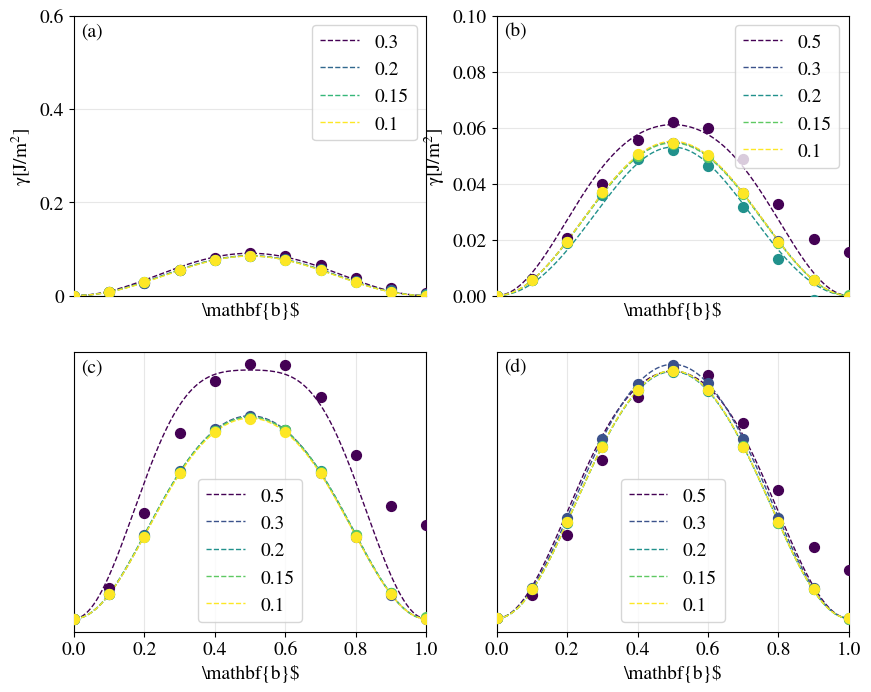

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
# fig, axs = plt.subplots(1, 4, figsize=(5 * 4, 5), squeeze=False)
fig, axs = plt.subplots(2, 2, figsize=(5 * 2, 4 * 2), squeeze=False)

gsfe_groups.plot_kpoints_convergence(
    structure_type='A2',
    formula='Li',
    gliding_plane='011',
    # directions=['010',],
    kpoints_distances=[0.3, 0.2, 0.15, 0.1],
    n_repeats=3,
    ax = axs[0, 0],
    fit=True,
    order=2,)
gsfe_groups.plot_kpoints_convergence(
    structure_type='A2',
    formula='Na',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax = axs[0, 1],
    fit=True,
    order=2,)
gsfe_groups.plot_kpoints_convergence(
    structure_type='A2',
    formula='Nb',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax = axs[1, 0],
    fit=True,
    order=2,)
gsfe_groups.plot_kpoints_convergence(
    structure_type='A2',
    formula='V',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=3,
    ax = axs[1, 1],
    fit=True,
    order=2,)

for ax in axs[:, 1]:
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.set_yticklabels([])

for ax in axs[0]:
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_ylim([0, 0.1])

for ax, label in zip(axs.flatten(), ['(a)', '(b)', '(c)', '(d)']):
    ax.set_xlim([0, 1])
    ax.set_xlabel(r"$\mathbf{b}$")
    ax.set_title("")
    ax.text(0.02, 0.93, label, transform=ax.transAxes)

axs[0, 0].set_yticks([0, 0.2, 0.4, 0.6])
axs[0, 0].set_yticklabels([0, 0.2, 0.4, 0.6])


fig.savefig("/home/yimzhang/Development/aiida/ductility/data/dislocation/a2_conv_k.pdf")

#### supercell convergence

In [24]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/A2/conv/n_repeats']
)

In [25]:
gsfe_groups.get_table()

Plane                                 011
Structure Material Layers K_Dist         
A2        Li       2      0.15    ✅ 93131
                   3      0.15    ✅ 93150
                   4      0.15    ✅ 93171
                   5      0.15    ✅ 93193
          Na       2      0.15    ✅ 93048
                   3      0.15    ✅ 93067
                   4      0.15    ✅ 93089
                   5      0.15    ✅ 93111
          Nb       2      0.30    ✅ 89422
                   3      0.30    ✅ 89441
                   4      0.30    ✅ 89461
                   5      0.30    ✅ 89482
          V        2      0.30    ✅ 89504
                   3      0.30    ✅ 89524
                   4      0.30    ✅ 89542
                   5      0.30    ✅ 89563

/home/yimzhang/Development/aiida/packages/aiida-analyser/aiida_analyser/dislocation/gsfe_latest.py:754: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


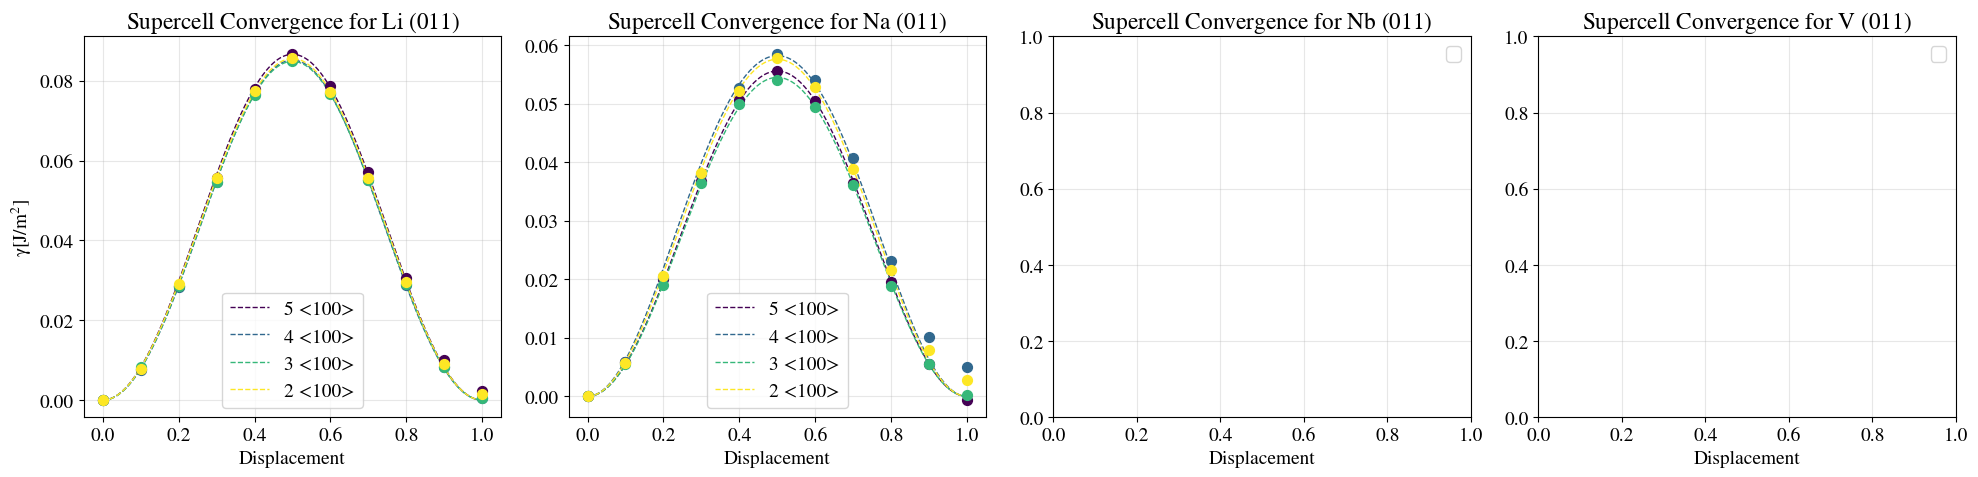

In [28]:

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 4, figsize=(5 * 4, 5), squeeze=False)
gsfe_groups.plot_supercell_convergence(
    structure_type='A2',
    formula='Li',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.15,
    ax = axs[0, 0],
    fit=True,
    order=2)
gsfe_groups.plot_supercell_convergence(
    structure_type='A2',
    formula='Na',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.15,
    ax = axs[0, 1],
    fit=True,
    order=2)
gsfe_groups.plot_supercell_convergence(
    structure_type='A2',
    formula='Nb',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.15,
    ax = axs[0, 2],
    fit=True,
    order=2)
gsfe_groups.plot_supercell_convergence(
    structure_type='A2',
    formula='V',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.15,
    ax = axs[0, 3],
    fit=True,
    order=2)
for ax in axs[0, 1:]:
    ax.set_ylabel('')
fig.tight_layout()
# fig.savefig('/home/yimzhang/Development/aiida/ductility/data/dislocation/a2_conv_supercell.pdf', dpi=300)

#### gsfe submission

In [7]:
ductility_grpname = f'gsfe/A2/vc-relax'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [7]:
import logging

v1_overrides['sfe'] = v1_overrides['sfe_relax']
# for material in ['Al',]:
for material in [ 'Nb', 'V']:
    structure = create_structure(material, 'bcc')
    builder = GSFERelaxWorkChain.get_builder_from_protocol(
        code=code,
        structure=structure,
        # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
        protocol='fast',
        overrides=v1_overrides,
        n_repeats = orm.Int(3),
        gliding_plane = orm.Str('011')
    )
    builder.kpoints_distance = orm.Float(0.2)
    builder.clean_workdir = orm.Bool(False)

    # builder.layer_spacings = orm.List([0.000, 0.002, 0.006, 0.012, 0.02, 0.036])
    # builder.pop('relax')
    # builder.pop('scf')
    # builder.pop('surface_energy')
    logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
    logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
    logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
    node = engine.submit(builder)
    # result, node = engine.run_get_node(builder)
    ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: relax.base_init_relax.pseudo_family
  warnings.warn(f'Foun

#### unrelaxed

In [16]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['dislocation/A2']
)

In [17]:
gsfe_groups.get_table()

Plane                                                           011      100
StructureType Formula Process       Layers K_Dist Conv_thr                  
A2            Li      GSFEWorkChain 4      0.15   0.000001  ✅ 31529  ✅ 39008
              Na      GSFEWorkChain 4      0.15   0.000001  ✅ 10419  ✅ 47032
              Nb      GSFEWorkChain 4      0.15   0.000001  ✅ 24294  ✅ 39721
              V       GSFEWorkChain 4      0.15   0.000001  ✅ 31787  ✅ 21938

In [18]:
surface_energy_results = gsfe_groups.get_surface_energies()

In [19]:
surface_energy_results

{'A2': {'011': {'Na': {'surface_energy': np.float64(0.20886432363175958)},
   'V': {'surface_energy': np.float64(2.4943889731899924)},
   'Nb': {'surface_energy': np.float64(2.1178802839133657)},
   'Li': {'surface_energy': np.float64(0.4957226665146591)}},
  '100': {'Na': {'surface_energy': np.float64(0.22011930348520306)},
   'V': {'surface_energy': np.float64(2.6003881863434346)},
   'Nb': {'surface_energy': np.float64(2.5223213787083094)},
   'Li': {'surface_energy': np.float64(0.46538495915738715)}}}}

AttributeError: Node<10419>: GSFE results output is not found

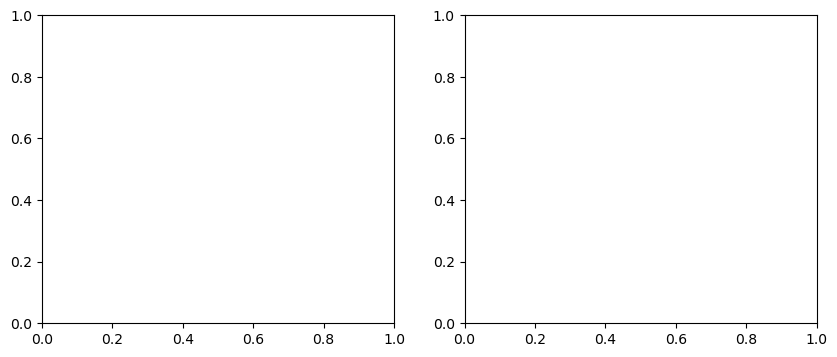

In [20]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)
results = gsfe_groups.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2, 4, 6])
axs[0, 0].set_yticklabels([0, 2, 4, 6], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_yticks([0, 1, 2, 3])
axs[0, 1].set_yticklabels([0, 1, 2, 3], fontsize=12)
axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
axs[0, 1].set_ylabel('')
axs[0, 1].set_xlabel('')
axs[0, 1].set_xticklabels([])
axs[0, 0].set_ylim([0, 6])
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_ylim([0, 3])
axs[0, 1].set_yticks([0, 0.5, 1, 1.5, 2])
axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5, 2], fontsize=12)
axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12)
# axs[0, 1].get_legend().remove()
fig.tight_layout()

#### relaxed

In [21]:
gsfe_groups = dislocation.GSFERelaxGroupData(
    groups = ['gsfe/A2/vc-relax']
)

In [22]:
gsfe_groups.get_table()

Plane                                                                                    011
Structure Material Process            Layers K_Dist Conv_thr                                
A2        Li       GSFERelaxWorkChain 3      0.2    5.0e-07 Ry (+- 9.6e-04 mJ/m^2)  ✅ 105090
          Na       GSFERelaxWorkChain 3      0.2    5.0e-07 Ry (+- 6.4e-04 mJ/m^2)  ✅ 105113
          Nb       GSFERelaxWorkChain 3      0.2    5.0e-07 Ry (+- 1.0e-03 mJ/m^2)  ✅ 105226
          V        GSFERelaxWorkChain 3      0.2    5.0e-07 Ry (+- 1.3e-03 mJ/m^2)  ✅ 105249

In [23]:
gsfe_groups._data

defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>()>,
            {'A2': defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>()>,
                         {'Li': defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                      {'011': defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                                   {'GSFERelaxWorkChain': defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                                                {3: defaultdict(<function aiida_ana

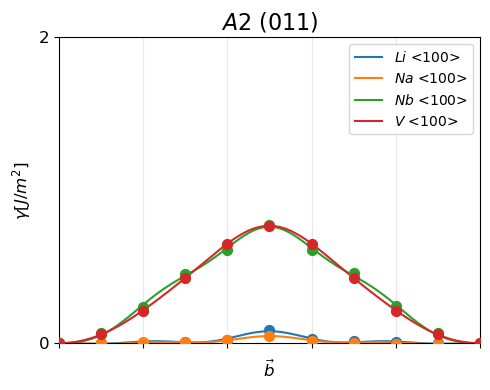

In [26]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 1, figsize=(5, 4), squeeze=False)
results = gsfe_groups.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2])
axs[0, 0].set_yticklabels([0, 2], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)

axs[0, 0].set_ylim([0, 2])

axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
# axs[0, 1].get_legend().remove()
fig.tight_layout()

In [29]:
results

{'A2': {'011': {'Li': {'100': {'usf': np.float64(0.078678934822628)}},
   'Na': {'100': {'usf': np.float64(0.047008051397168904)}},
   'Nb': {'100': {'usf': np.float64(0.7615185413126682)}},
   'V': {'100': {'usf': np.float64(0.7679595415172749)}}}}}

In [30]:
# 格式： "键": [(数值, "引文Key"), (数值, "引文Key"), ...]
literature_dict = {
    "Li": {"usfe_011": [(71, "Zhang2023")]},
    "Na": {"usfe_011": [(48, "Zhang2023")]},
    "Nb": {"usfe_011": [(674, "Zhang2023")]},
    "V":  {"usfe_011": [(713, "Zhang2023")]},
    "KCl": {"usfe_100": [(193.8, "Liu2012")]},
    "NaCl": {"usfe_100": [(225.2, "Liu2012")]}
}

In [31]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

def format_cell(calc_val, material, lit_key, is_surface=False):
    """
    处理单元格，将计算值与文献元组列表合并
    """
    contents = []
    
    # 1. 处理本代码计算得到的数值
    if calc_val is not None and str(calc_val) != '-':
        # 按照原逻辑，表面能不乘1000，其余乘
        real_val = float(calc_val) * 1000 if not is_surface else float(calc_val)
        contents.append(f"{real_val:.2f}")
    elif not literature_dict.get(material, {}).get(lit_key):
        # 如果计算值为空且文献也为空，返回横杠
        return "-"

    # 2. 处理文献元组列表 [(数值, 标签), ...]
    lit_entries = literature_dict.get(material, {}).get(lit_key, [])
    for val, cite_key in lit_entries:
        # 生成类似 "97 \cite{Tu2019}" 或 "21$\pm$7 \cite{Dillamore1965}"
        entry_str = f"{val} \\cite{{{cite_key}}}"
        contents.append(entry_str)
    
    # 3. 用 \newline 连接所有项
    return " \\newline ".join(contents)

headers = [
    "Material",
    r"$\gamma^{\rm USEF}_{100}$",
    r"$\gamma^{\rm USEF}_{011}$",
    r"$\gamma^{\rm surface}_{100}$",
    r"$\gamma^{\rm surface}_{011}$",
    # r"$\frac{G}{B}_{100}$"
    ]
data = []
elements = sorted(list(results['A2']['100'].keys())) # ['Ag', 'Al', ...]
# data = np.array([
#     ['Al', 31.45, 192.61, 211.21 , 1306.95, '-'],
#     ['Pb', 53.88, 20.32, 592.68, '-', '-'],
#     ['Li', 525.17, 20.32, 592.68, '-', '-'],
#     ['Na', 53.88, 20.32, 592.68, '-', '-'],
#     ['V', 53.88, 20.32, 592.68, '-', '-'],
#     ['Nb', 53.88, 20.32, 592.68, '-', '-'],
#     ['VC', '-', '-', '-', '-', '-'],
#     ['MoC', '-', '-', '-', '-', '-'],
#     ['AsTe', '410.69', '319.05', '-', '-', '-'],
#     ['CrH', '2245.38', '4474.67', '-', '-', '-'],
#     ['TaS2', '-', '-', '-', '-', '-'],
#     ['TaSe2', '-', '-', '-', '-', '-'],
#     ['CoNbSb', '-', '-', '-', '-', '-'],
#     ['TaCoSb', '-', '-', '-', '-', '-'],
#     ['ZrRuSb', '-', '-', '-', '-', '-'],
#     ['TaRu3C', '-', '-', '-', '-', '-'],
#     ['NbRu3C', '-', '-', '-', '-', '-'],
# ])
for elem in elements:
    row = [
        elem,  # Material
        format_cell(results['A2']['100'][elem]['110']['usf'], elem, "usfe_100"),
        format_cell(results['A2']['100'][elem]['110']['usf'], elem, "usfe_011"),
        format_cell(surface_energy_results['A1']['100'][elem]['surface_energy']*1000, elem, "surf_100", True),
        format_cell(surface_energy_results['A1']['011'][elem]['surface_energy']*1000, elem, "surf_011", True),
    ]
    data.append(row)
    
df = pd.DataFrame(data=data, columns=headers)
latex_output = df.style.hide(axis="index").to_latex(
    caption="Generalized stacking fault energy and surface energies.",
    label="tab:table2",
    environment="table*",
    position="htbp",
    hrules=True
)
print(latex_output)
# format_dict = {col_name: '{:.2f}' for col_name in df.columns.tolist()[1:]}
# for col in headers[1:]:
#     # This line forces each column to become numeric.
#     # errors='coerce' will turn any non-numeric strings (like 'N/A')
#     # into NaN (Not a Number), which .style.format() can handle.
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# styler = df.style.format(format_dict).hide(axis="index")
# print(
#     styler.to_latex(
#         caption="Generalized stacking fault energy for top ductile superconductors.", 
#         label="tab:table2", 
#         environment="table",
#         position="htbp",)
# )

KeyError: '100'

### GSFE for $B_1$

#### kpoints convergence

In [ ]:
for material in ['V', 'Nb',]:
    for kpoints_distance in [0.5, 0.3, 0.2, 0.15, 0.1]:
        structure = create_structure(material, 'bcc')
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=3,
            gliding_plane='011',
        )
        builder.kpoints_distance = orm.Float(kpoints_distance)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        # node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        # ductility_grp.add_nodes([node])

In [3]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/B1/conv/k']
)

In [4]:
gsfe_groups.get_table()

Plane                                 011      100
Structure Material Layers K_Dist                  
B1        ClK      4      0.10    ✅ 68544  ✅ 71193
                          0.15    ✅ 68524  ✅ 71173
                          0.20    ✅ 68500  ✅ 71154
                          0.30    ✅ 68480  ✅ 71129
                          0.50    ✅ 68461  ✅ 71107
          ClNa     4      0.10    ✅ 68411  ✅ 71075
                          0.15    ✅ 68389  ✅ 71053
                          0.20    ✅ 68366  ✅ 71029
                          0.30    ✅ 68345  ✅ 71009
                          0.50    ✅ 68326  ✅ 70990

(<Axes: title={'center': 'K-points Convergence for $ClK$ (011)'}, xlabel='Displacement', ylabel='$\\gamma [J/m^2]$'>,
 {0.5: {'100': {'usf': np.float64(1.6358361581966885),
    's': np.float64(-0.27181363942120274)},
   '010': {'usf': np.float64(1.2401597847673242),
    's': np.float64(-0.12150541619168342)}},
  0.3: {'100': {'usf': np.float64(1.6363500602588708),
    's': np.float64(-0.2718072550066777)},
   '010': {'usf': np.float64(1.2386473384625196),
    's': np.float64(-0.12113083290506865)}},
  0.2: {'100': {'usf': np.float64(1.636356732374585),
    's': np.float64(-0.27180758357718293)},
   '010': {'usf': np.float64(1.2386560709619832),
    's': np.float64(-0.12115650985915956)}},
  0.15: {'100': {'usf': np.float64(1.6363565892271454),
    's': np.float64(-0.2718079104357394)},
   '010': {'usf': np.float64(1.2386401473677653),
    's': np.float64(-0.12111722616388998)}},
  0.1: {'100': {'usf': np.float64(1.6363561650880616),
    's': np.float64(-0.2718081213615829)},
   '010': 

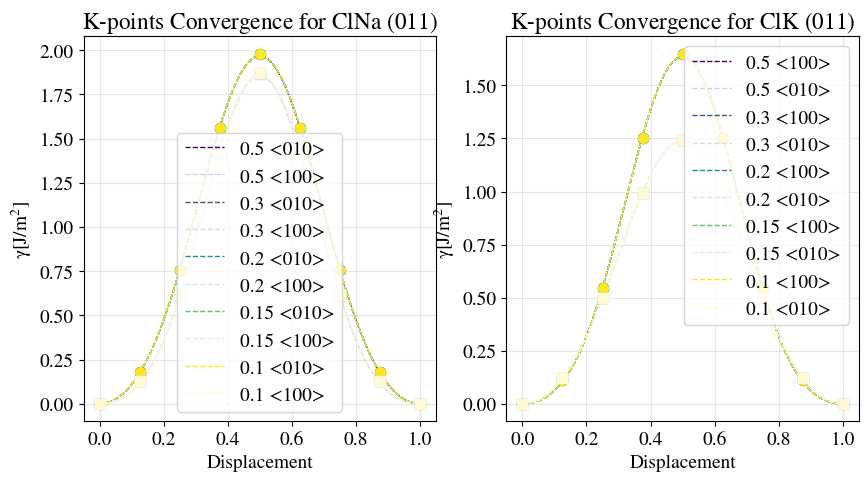

In [8]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 2, figsize=(5 * 2, 5), squeeze=False)

gsfe_groups.plot_kpoints_convergence(
    structure_type='B1',
    formula='ClNa',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.3, 0.2, 0.15, 0.1],
    n_repeats=4,
    ax = axs[0, 0],
    fit=True,
    order=2,)
gsfe_groups.plot_kpoints_convergence(
    structure_type='B1',
    formula='ClK',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=4,
    ax = axs[0, 1],
    fit=True,
    order=2,)


#### supercell convergence

In [ ]:
for material in ['NaCl']:
    for n_repeats in [2, 3, 4, 5]:
        structure = read_structure_from_file(material)
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=n_repeats,
            gliding_plane='100',
        )
        builder.kpoints_distance = orm.Float(0.5)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        ductility_grp.add_nodes([node])

In [ ]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/A1/conv/n_repeats']
)
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 3, figsize=(5 * 3, 5), squeeze=False)
gsfe_groups.plot_kpoints_convergence(
    structure_type='B1',
    formula='ClK',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=4,
    ax = axs[0, 0],
    fit=True,
    order=2,)
gsfe_groups.plot_kpoints_convergence(
    structure_type='B1',
    formula='ClNa',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    n_repeats=4,
    ax = axs[0, 1],
    fit=True,
    order=2,)

#### gsfe submission

In [37]:
ductility_grpname = f'gsfe/B1/vc-relax'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [10]:
import logging

v1_overrides['sfe'] = v1_overrides['sfe_relax']
for material in ['NaCl', 'KCl']:
    structure = read_structure_from_file(material)
    builder = GSFERelaxWorkChain.get_builder_from_protocol(
        code=code,
        structure=structure,
        # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
        protocol='fast',
        overrides=v1_overrides,
        n_repeats = orm.Int(4),
        gliding_plane = orm.Str('011')
    )
    builder.kpoints_distance = orm.Float(0.5)
    builder.clean_workdir = orm.Bool(False)

    # builder.layer_spacings = orm.List([0.000, 0.002, 0.006, 0.012, 0.02, 0.036])
    # builder.pop('relax')
    # builder.pop('scf')
    # builder.pop('surface_energy')
    logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
    logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
    logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
    # result, node = engine.run_get_node(builder)
    node = engine.submit(builder)
    ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

In [38]:
printer = Printer( builder)
printer.print()

NameError: name 'builder' is not defined

In [ ]:
for material in ['AsTe', 'CrH', 'VC']:
    structure = read_structure_from_file(material)
    builder = GSFEWorkChain.get_builder_from_protocol(
        code=code,
        structure=structure,
        # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
        protocol='fast',
        overrides=v1_overrides,
    )
    builder.kpoints_distance = orm.Float(0.15)
    builder.clean_workdir = orm.Bool(False)
    builder.n_repeats = orm.Int(4)
    builder.gliding_plane = orm.Str('011')
    # builder.layer_spacings = orm.List([0.000, 0.002, 0.006, 0.012, 0.02, 0.036])
    # builder.pop('relax')
    # builder.pop('scf')
    # builder.pop('surface_energy')
    logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
    logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
    logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
    # node = engine.submit(builder)
    # result, node = engine.run_get_node(builder)
    # ductility_grp.add_nodes([node])

In [9]:
gsfe_groups = dislocation.GSFERelaxGroupData(
    groups = ['gsfe/B1/vc-relax']
)

In [10]:
gsfe_groups.get_table()

Plane                                  011
Structure Material Layers K_Dist          
B1        ClK      4      0.5     ✅ 102698
          ClNa     4      0.5     ✅ 102675

In [5]:
gsfe_groups.dump(datadir)

INFO     extract GSFERelaxWorkChain<100303> ->                                                                     
         /home/yimzhang/Development/aiida/ductility/data/dislocation/B1/ClNa/011/GSFERelaxWorkChain/4/0.15/100303  
         (23 direct children: relax, generate_faulted_structures, create_kpoints_from_distance,                    
         create_kpoints_from_distance_sfe, scf, sfe_010_000, ... (+17 more))

INFO     complete GSFERelaxWorkChain<100303>

INFO     extract GSFERelaxWorkChain<100324> ->                                                                     
         /home/yimzhang/Development/aiida/ductility/data/dislocation/B1/ClK/011/GSFERelaxWorkChain/4/0.15/100324   
         (23 direct children: relax, generate_faulted_structures, create_kpoints_from_distance,                    
         create_kpoints_from_distance_sfe, scf, sfe_010_000, ... (+17 more))

INFO     complete GSFERelaxWorkChain<100324>

/tmp/ipykernel_446476/2404219240.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend(loc='upper right', fontsize=10)


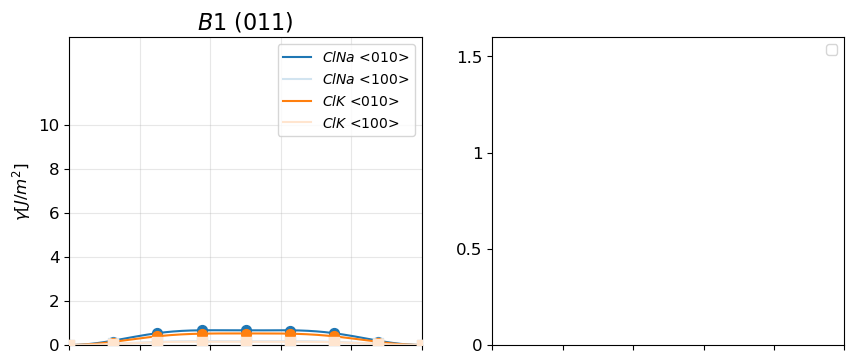

In [13]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)

# results = gsfe_groups.fit(axs=numpy.array([
#     [axs[0, 0]],
#     [axs[0, 1]],
#     [axs[0, 2]]
# ]))
# analyser = GSFERelaxWorkChainAnalyser(orm.load_node(102698))
# analyser.fit(ax = axs[0, 0])
# analyser = GSFERelaxWorkChainAnalyser(orm.load_node(102675))
# analyser.fit(ax = axs[0, 0])
results = gsfe_groups.fit(axs=axs)

axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_ylim([0, 14])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2, 4, 6, 8, 10])
axs[0, 0].set_yticklabels([0, 2, 4, 6, 8, 10], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)

axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_yticks([0, 0.5, 1, 1.5])
axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5], fontsize=12)
axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
axs[0, 1].set_ylabel('')
axs[0, 1].set_xlabel('')
axs[0, 1].set_xticklabels([])
axs[0, 1].set_ylim([0, 1.6])
axs[0, 1].legend(loc='upper right', fontsize=10)


In [14]:
results

{'B1': {'011': {'ClNa': {'010': {'usf': np.float64(0.6711045261969054),
     's': np.float64(0.2075682185484391)},
    '100': {'usf': np.float64(0.17175014821032777),
     's': np.float64(0.06087741547538351)}},
   'ClK': {'010': {'usf': np.float64(0.5256107570903688),
     's': np.float64(0.13322092450646866)},
    '100': {'usf': np.float64(0.14946731862846166),
     's': np.float64(0.052546134759670765)}}}}}

/tmp/ipykernel_4096125/2238468894.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 0].legend(loc='upper right', fontsize=10)


AttributeError: 'NoneType' object has no attribute 'remove'

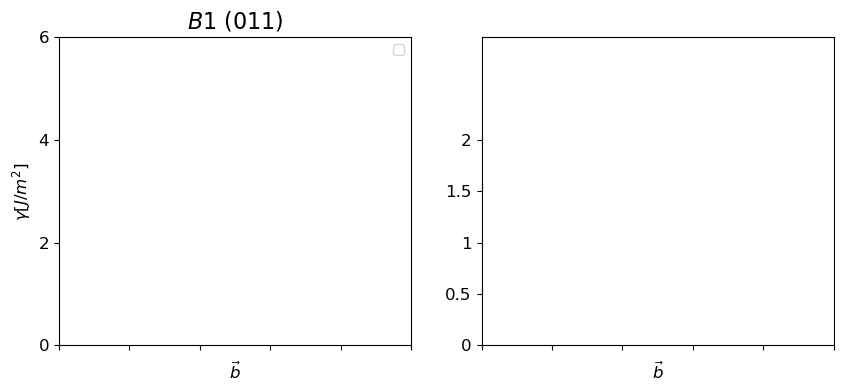

In [14]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)
results = gsfe_groups.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2, 4, 6])
axs[0, 0].set_yticklabels([0, 2, 4, 6], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_yticks([0, 1, 2, 3])
axs[0, 1].set_yticklabels([0, 1, 2, 3], fontsize=12)
axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
axs[0, 1].set_ylabel('')
axs[0, 1].set_xlabel('')
axs[0, 1].set_xticklabels([])
axs[0, 0].set_ylim([0, 6])
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_ylim([0, 3])
axs[0, 1].set_yticks([0, 0.5, 1, 1.5, 2])
axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5, 2], fontsize=12)
axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].get_legend().remove()
fig.tight_layout()

In [87]:
results

{'B1': {'011': {'CV': {'010': {'usf': np.float64(10.052151886704916),
     's': np.float64(9.419066066916768)},
    '100': {'usf': np.float64(9.724946121128298),
     's': np.float64(9.050697649622764)}},
   'ClNa': {'010': {'usf': np.float64(1.9691998300239832),
     's': np.float64(1.8315919584850917)},
    '100': {'usf': np.float64(1.859730134693715),
     's': np.float64(1.711331380413342)}},
   'CrH': {'010': {'usf': np.float64(4.621976865210867),
     's': np.float64(4.352145093074742)},
    '100': {'usf': np.float64(4.790115205776541),
     's': np.float64(4.490615429808913)}},
   'AsTe': {'100': {'usf': np.float64(3.359853642164365),
     's': np.float64(3.1076251222638875)},
    '010': {'usf': np.float64(0.35380139465522475),
     's': np.float64(0.18999144519971367)}},
   'ClK': {'010': {'usf': np.float64(1.2386400525248646),
     's': np.float64(1.1559615915452541)},
    '100': {'usf': np.float64(1.6363565330637222),
     's': np.float64(1.5064337868261544)}}},
  '100': {'CV

In [90]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

def format_cell(calc_val, literature, is_surface=False):
    """
    处理单元格，将计算值与文献元组列表合并
    """
    contents = []
    
    # 1. 处理本代码计算得到的数值
    if calc_val is not None and str(calc_val) != '-':
        # 按照原逻辑，表面能不乘1000，其余乘
        real_val = float(calc_val) * 1000 if not is_surface else float(calc_val)
        contents.append(f"{real_val:.2f}")
    elif not literature:
        # 如果计算值为空且文献也为空，返回横杠
        return "-"

    # 2. 处理文献元组列表 [(数值, 标签), ...]
    if literature:
        for val, cite_key in literature:
            # 生成类似 "97 \cite{Tu2019}" 或 "21$\pm$7 \cite{Dillamore1965}"
            entry_str = f"{val} \\cite{{{cite_key}}}"
            contents.append(entry_str)
        
    # 3. 用 \newline 连接所有项
    return " \\newline ".join(contents)

headers = [
    "Material",
    r"$\gamma^{\rm USEF}_{011}$",
    r"$\gamma^{\rm USFE}_{100}$",
    # r"$\gamma^{\rm surface}_{100}$",
    r"$\gamma^{\rm surface}_{011}$",
    r"$\text{Rice ratio}_{100}$",
    r"$\frac{G}{B}$"]
data = []
elements = sorted(list(results['B1']['011'].keys())) 
print(elements)
for elem in elements:
    row = [
        elem,  # Material
        format_cell(results['B1']['011'][elem]['100']['usf'], literature=None),
        format_cell(results['B1']['100'][elem]['100']['usf'],literature=None),
        # format_cell(surface_energy_results['C1b']['100'][elem]['surface_energy']*1000, literature=None, is_surface=True),
        format_cell(surface_energy_results['B1']['011'][elem]['surface_energy']*1000, literature=None, is_surface=True),
        format_cell(results['B1']['100'][elem]['100']['usf'] / (surface_energy_results['B1']['011'][elem]['surface_energy']*1000), literature=None),
        "-",
    ]
    data.append(row)
    
df = pd.DataFrame(data=data, columns=headers)
latex_output = df.style.hide(axis="index").to_latex(
    caption="Generalized stacking fault energy and surface energies.",
    label="tab:table2",
    environment="table*",
    position="htbp",
    hrules=True
)
print(latex_output)


['AsTe', 'CV', 'ClK', 'ClNa', 'CrH']
\begin{table*}[htbp]
\caption{Generalized stacking fault energy and surface energies.}
\label{tab:table2}
\begin{tabular}{llllll}
\toprule
Material & $\gamma^{\rm USEF}_{011}$ & $\gamma^{\rm USFE}_{100}$ & $\gamma^{\rm surface}_{011}$ & $\text{Rice ratio}_{100}$ & $\frac{G}{B}$ \\
\midrule
AsTe & 3359.85 & 170.10 & 402.86 & 0.42 & - \\
CV & 9724.95 & 1398.29 & 3576.34 & 0.39 & - \\
ClK & 1636.36 & 87.41 & 267.47 & 0.33 & - \\
ClNa & 1859.73 & 140.39 & 350.96 & 0.40 & - \\
CrH & 4790.12 & 710.09 & 3081.37 & 0.23 & - \\
\bottomrule
\end{tabular}
\end{table*}



### GSFE for $B_2$

In [19]:
gsfe_groups = dislocation.GSFEGroupData(
    groups = ['dislocation/B2']
)

In [20]:
gsfe_groups.get_table()

Plane                                 011      100
Structure Material Layers K_Dist                  
B2        NiTi     2      0.15    ✅ 25889  ✅ 33031
                   4      0.15    ✅ 42621   ✅ 1796

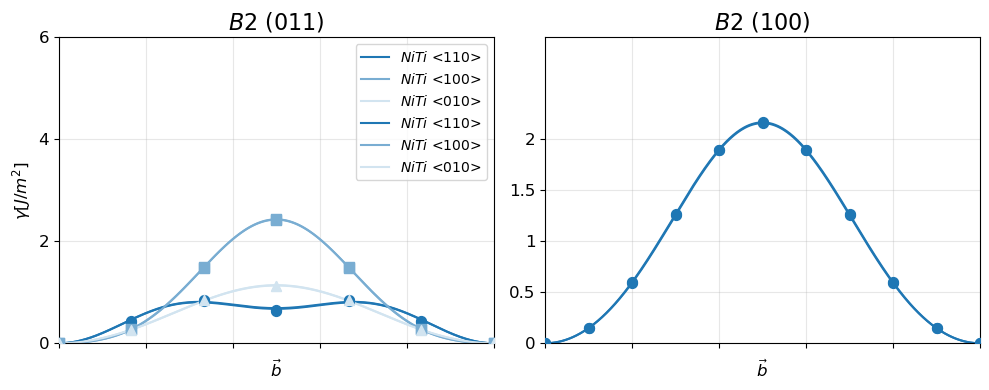

In [22]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 2, figsize=(5*2, 4), squeeze=False)
results = gsfe_groups.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2, 4, 6])
axs[0, 0].set_yticklabels([0, 2, 4, 6], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_yticks([0, 1, 2, 3])
axs[0, 1].set_yticklabels([0, 1, 2, 3], fontsize=12)
axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
axs[0, 1].set_ylabel('')
axs[0, 1].set_xlabel('')
axs[0, 1].set_xticklabels([])
axs[0, 0].set_ylim([0, 6])
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_ylim([0, 3])
axs[0, 1].set_yticks([0, 0.5, 1, 1.5, 2])
axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5, 2], fontsize=12)
axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].get_legend().remove()

fig.tight_layout()

In [11]:
results

{'B2': {'011': {'NiTi': {'110': {'usf': np.float64(0.8022960190650952),
     's': np.float64(0.7151363428919686)},
    '100': {'usf': np.float64(2.431114696041276),
     's': np.float64(2.2297594481274525)},
    '010': {'usf': np.float64(1.1331108908653176),
     's': np.float64(1.0740118658272797)}}},
  '100': {'NiTi': {'100': {'usf': np.float64(0.6868068000012468)}}}}}

### GSFE for $C1_b$

#### kpoints convergence

In [ ]:
ductility_grpname = f'gsfe/C1b/conv/k'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [ ]:
import logging
for material in ['TiAlPt',]:
    for kpoints_distance in [0.5, 0.3, 0.2, 0.15]:
        structure = read_structure_from_file(material)
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=4,
            gliding_plane='011',
        )
        builder.kpoints_distance = orm.Float(kpoints_distance)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

In [6]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/C1b/conv/k']
)

In [ ]:
gsfe_groups.get_table()

Plane                                       011
Structure Material Layers K_Dist               
C1_b      CoNbSb   4      0.10    ❌ (403) 55417
                          0.15          ✅ 55398
                          0.20          ✅ 55374
                          0.30          ✅ 55354
                          0.50          ✅ 55335
          RuSbTi   4      0.10          ✅ 75077
                          0.15          ✅ 75056
                          0.20          ✅ 75035
                          0.30          ✅ 75015
                          0.50          ✅ 74996
          RuSbZr   4      0.10          ✅ 75209
                          0.15          ✅ 75189
                          0.20          ✅ 75169
                          0.30          ✅ 75148
                          0.50          ✅ 75131

In [ ]:
gsfe_groups.dump(datadir)

Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.5/55335
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.3/55354
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.2/55374
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.15/55398
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.1/55417
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/RuSbTi/011/GSFEWorkChain/4/0.5/74996
Extraction complete.
Starting extraction to directory: /home/yimzhang/Developm

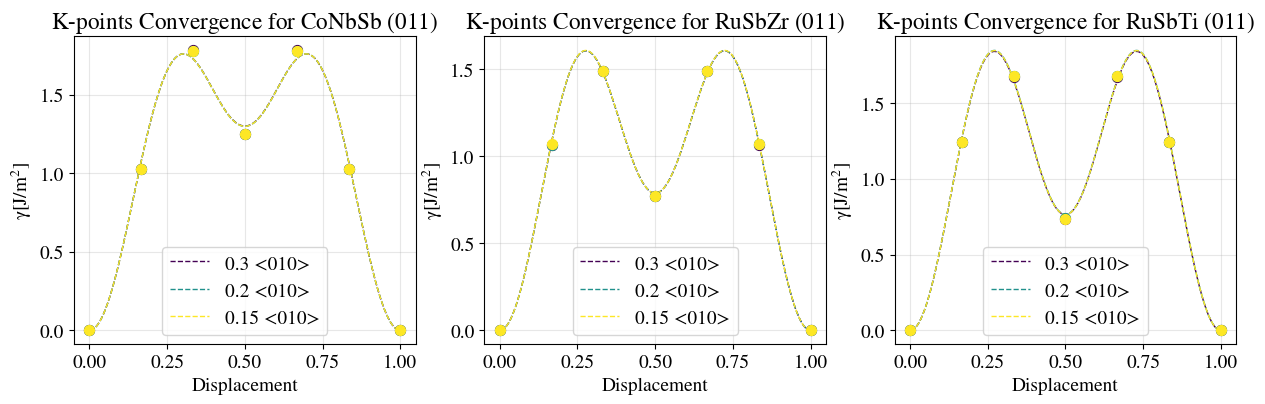

In [8]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 3, figsize=(5 * 3, 4), squeeze=False)

kconv_results = {}


kconv_results['CoNbSb'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='C1_b',
    formula='CoNbSb',
    gliding_plane='011',
    directions=['010',],
    kpoints_distances=[ 0.3, 0.2, 0.15],
    n_repeats=4,
    ax=axs[0, 0],
    fit=True,
    order=2)
kconv_results['RuSbZr'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='C1_b',
    formula='RuSbZr',
    gliding_plane='011',
    directions=['010',],
    kpoints_distances=[ 0.3, 0.2, 0.15],
    n_repeats=4,
    ax=axs[0, 1],
    fit=True,
    order=2)
kconv_results['RuSbTi'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='C1_b',
    formula='RuSbTi',
    gliding_plane='011',
    directions=['010',],
    kpoints_distances=[ 0.3, 0.2, 0.15],
    n_repeats=4,
    ax=axs[0, 2],
    fit=True,
    order=2)


#### supercell convergence

In [ ]:
ductility_grpname = f'gsfe/C1b/conv/n_repeats'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [ ]:
import logging
for material in ['TiAlPt',]:
    for kpoints_distance in [0.5, 0.3, 0.2, 0.15]:
        structure = read_structure_from_file(material)
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=4,
            gliding_plane='011',
        )
        builder.kpoints_distance = orm.Float(kpoints_distance)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        # node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        # ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

In [4]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/C1b/conv/n_repeats']
)

In [10]:
gsfe_groups.get_table()

Plane                                 011
Structure Material Layers K_Dist         
C1_b      CoNbSb   2      0.3     ✅ 81783
                   3      0.3     ✅ 81802
                   4      0.3     ✅ 81822
                   5      0.3     ✅ 81841
          RuSbTi   2      0.3     ✅ 81895
                   3      0.3     ✅ 81914
                   4      0.3     ✅ 81934
                   5      0.3     ✅ 81954
          RuSbZr   2      0.3     ✅ 81985
                   3      0.3     ✅ 82007
                   4      0.3     ✅ 82027
                   5      0.3     ✅ 82049

In [7]:
gsfe_groups.dump(datadir)

Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.5/55335
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.3/55354
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.2/55374
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.15/55398
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/CoNbSb/011/GSFEWorkChain/4/0.1/55417
Extraction complete.
Starting extraction to directory: /home/yimzhang/Development/aiida/ductility/data/dislocation/C1_b/RuSbTi/011/GSFEWorkChain/4/0.5/74996
Extraction complete.
Starting extraction to directory: /home/yimzhang/Developm

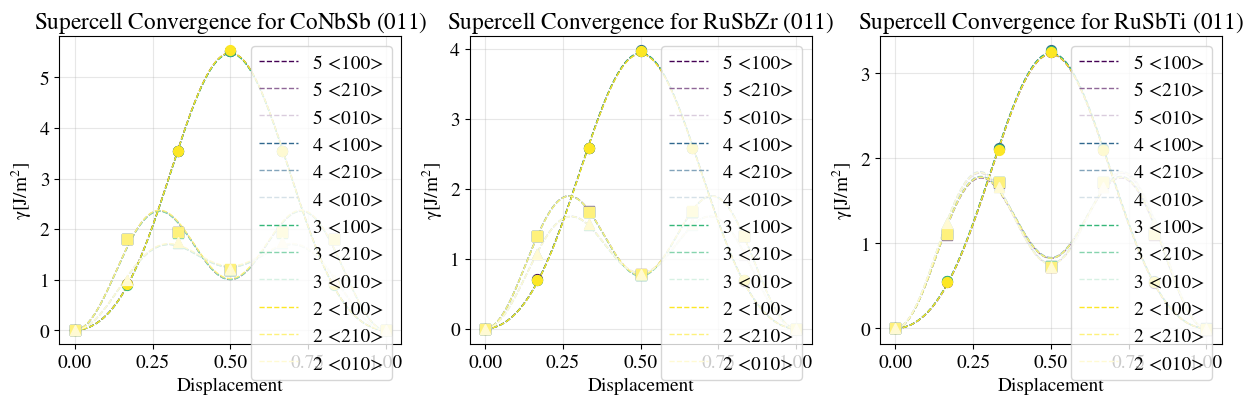

In [5]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 3, figsize=(5 * 3, 4), squeeze=False)

kconv_results = {}


kconv_results['CoNbSb'] = gsfe_groups.plot_supercell_convergence(
    structure_type='C1_b',
    formula='CoNbSb',
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3],
    # n_repeats=4,
    kpoints_distances=0.3,
    ax=axs[0, 0],
    fit=True,
    order=2)
kconv_results['RuSbZr'] = gsfe_groups.plot_supercell_convergence(
    structure_type='C1_b',
    formula='RuSbZr',
    gliding_plane='011',
    # directions=['010',],
    kpoints_distances=0.3,
    # n_repeats=4,
    ax=axs[0, 1],
    fit=True,
    order=2)
kconv_results['RuSbTi'] = gsfe_groups.plot_supercell_convergence(
    structure_type='C1_b',
    formula='RuSbTi',
    gliding_plane='011',
    # directions=['010',],
    kpoints_distances=0.3,
    # n_repeats=4,
    ax=axs[0, 2],
    fit=True,
    order=2)


#### gsfe submission

In [3]:
ductility_grpname = f'gsfe/C1b/vc-relax'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [ ]:
import logging

v1_overrides['sfe'] = v1_overrides['sfe_relax']
# for material in ['Al',]:
for material in ['TiSbRu', 'ZrRuSb', ]:
# for material in ['NbCoSb']:
    structure = read_structure_from_file(material)
    builder = GSFERelaxWorkChain.get_builder_from_protocol(
        code=code,
        structure=structure,
        # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
        protocol='fast',
        overrides=v1_overrides,
        n_repeats = orm.Int(3),
        gliding_plane = orm.Str('011')
    )
    builder.kpoints_distance = orm.Float(0.3)
    builder.clean_workdir = orm.Bool(False)

    # builder.layer_spacings = orm.List([0.000, 0.002, 0.006, 0.012, 0.02, 0.036])
    # builder.pop('relax')
    # builder.pop('scf')
    # builder.pop('surface_energy')
    logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
    logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
    logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
    node = engine.submit(builder)
    # result, node = engine.run_get_node(builder)
    ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

In [15]:
gsfe_groups = dislocation.GSFEGroupData(
    groups = ['gsfe/C1b/vc-relax']
)

In [16]:
gsfe_groups.get_table()

""


In [5]:
surface_energy_results = gsfe_groups.get_surface_energies()

Failed to fit/plot 42538: scf or surface_energy is not found


/tmp/ipykernel_446476/1709743415.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 0].legend(loc='upper right', fontsize=10)


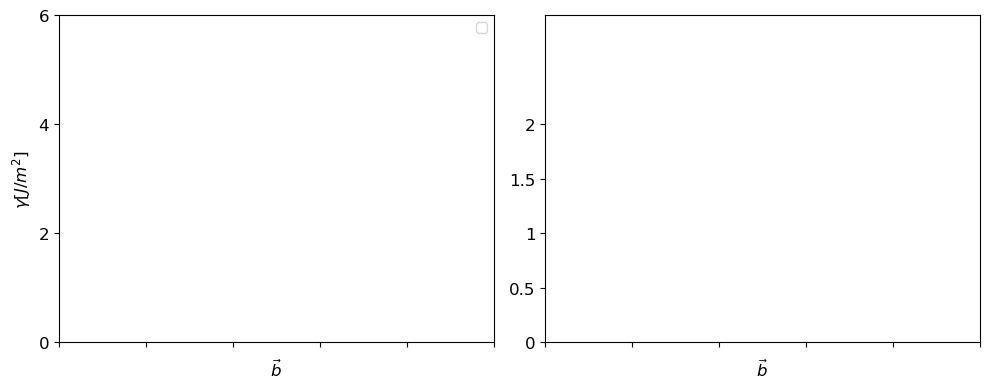

In [18]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)
results = gsfe_groups.fit(axs=axs)
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 2, 4, 6])
axs[0, 0].set_yticklabels([0, 2, 4, 6], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_yticks([0, 1, 2, 3])
axs[0, 1].set_yticklabels([0, 1, 2, 3], fontsize=12)
axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
axs[0, 1].set_ylabel('')
axs[0, 1].set_xlabel('')
axs[0, 1].set_xticklabels([])
axs[0, 0].set_ylim([0, 6])
axs[0, 1].set_xlim([0, 1])
axs[0, 1].set_ylim([0, 3])
axs[0, 1].set_yticks([0, 0.5, 1, 1.5, 2])
axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5, 2], fontsize=12)
axs[0, 0].set_xlabel(r'$\vec{b}$', fontsize=12)
axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12)
# axs[0, 1].get_legend().remove()
fig.tight_layout()

In [7]:
surface_energy_results

{'C1_b': {'011': {'RuSbZr': {'surface_energy': np.float64(1.42746157721213)},
   'CoNbSb': {'surface_energy': np.float64(1.3441738577273208)},
   'RuSbTi': {'surface_energy': np.float64(1.4916126456467529)}},
  '100': {'CoNbSb': {'surface_energy': np.float64(1.8548632623454868)},
   'RuSbTi': {'surface_energy': np.float64(1.582350763763875)}}}}

In [8]:
results

{'C1_b': {'011': {'RuSbZr': {'210': {'usf': np.float64(1.8983982474968042),
     's': np.float64(0.9952382054488167)},
    '010': {'usf': np.float64(1.6048462611499923),
     's': np.float64(0.9658590142582125)},
    '100': {'usf': np.float64(3.941399989405516),
     's': np.float64(3.6685617259421863)}},
   'CoNbSb': {'210': {'usf': np.float64(2.3607488731792428),
     's': np.float64(1.2917106324499537)},
    '010': {'usf': np.float64(1.6978076082099993),
     's': np.float64(1.366450568233772)},
    '100': {'usf': np.float64(5.484216753318461),
     's': np.float64(5.09001036141392)}},
   'RuSbTi': {'010': {'usf': np.float64(1.84578934187795),
     's': np.float64(0.9929262309790737)},
    '210': {'usf': np.float64(1.7926039665526317),
     's': np.float64(1.0407467243814714)},
    '100': {'usf': np.float64(3.2468696307313447),
     's': np.float64(3.019080389538356)}}},
  '100': {'RuSbZr': {'110': {'usf': np.float64(1.9329997401659562)}},
   'CoNbSb': {'110': {'usf': np.float64(2.1

#### surface submission

In [3]:
surface_group = SurfaceEnergyData(groups = ['surface/C1b/conv/k'])

In [10]:
surface_group.get_table()

Plane                                 011      100
Structure Material Layers K_Dist                  
C1_b      CoNbSb   3      0.20             ✅ 49852
                          0.30             ✅ 49828
                          0.40             ✅ 49808
                          0.50             ✅ 49789
                   4      0.15    ✅ 48983         
                          0.20    ✅ 48964  ✅ 48839
                          0.30    ✅ 48945  ✅ 50088
                          0.40    ✅ 48924         
                          0.50    ✅ 48901  ✅ 48776
          RuSbTi   4      0.30    ✅ 94879         
                          0.40    ✅ 94859         
                          0.50    ✅ 94840         
          RuSbZr   4      0.20    ✅ 95049         
                          0.30    ✅ 95028         
                          0.40    ✅ 95008         
                          0.50    ✅ 94989

AttributeError: 'collections.defaultdict' object has no attribute 'outputs'

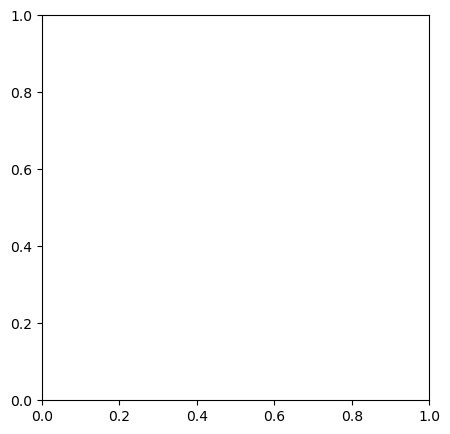

In [11]:
surface_group.plot()

In [18]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

def format_cell(calc_val, literature, is_surface=False):
    """
    处理单元格，将计算值与文献元组列表合并
    """
    contents = []
    
    # 1. 处理本代码计算得到的数值
    if calc_val is not None and str(calc_val) != '-':
        # 按照原逻辑，表面能不乘1000，其余乘
        real_val = float(calc_val) * 1000 if not is_surface else float(calc_val)
        contents.append(f"{real_val:.2f}")
    elif not literature:
        # 如果计算值为空且文献也为空，返回横杠
        return "-"

    # 2. 处理文献元组列表 [(数值, 标签), ...]
    if literature:
        for val, cite_key in literature:
            # 生成类似 "97 \cite{Tu2019}" 或 "21$\pm$7 \cite{Dillamore1965}"
            entry_str = f"{val} \\cite{{{cite_key}}}"
            contents.append(entry_str)
        
    # 3. 用 \newline 连接所有项
    return " \\newline ".join(contents)

headers = [
    "Material",
    r"$\gamma^{\rm USEF}_{011}$",
    r"$\gamma^{\rm USFE}_{100}$",
    # r"$\gamma^{\rm surface}_{100}$",
    r"$\gamma^{\rm surface}_{011}$",
    r"$\text{Rice ratio}_{011}$",
    r"$\frac{G}{B}$"]
data = []
elements = sorted(list(results['C1_b']['011'].keys())) 
print(elements)
for elem in elements:
    row = [
        elem,  # Material
        format_cell(kconv_results[elem][1][0.2]['010']['usf'], literature=None),
        format_cell(results['C1_b']['100'][elem]['110']['usf'],literature=None),
        # format_cell(surface_energy_results['C1b']['100'][elem]['surface_energy']*1000, literature=None, is_surface=True),
        format_cell(surface_energy_results['C1_b']['011'][elem]['surface_energy']*1000, literature=None, is_surface=True),
        format_cell(kconv_results[elem][1][0.2]['010']['usf'] / (surface_energy_results['C1_b']['011'][elem]['surface_energy']*1000), literature=None),
        "-",
    ]
    data.append(row)
    
df = pd.DataFrame(data=data, columns=headers)
latex_output = df.style.hide(axis="index").to_latex(
    caption="Generalized stacking fault energy and surface energies.",
    label="tab:table2",
    environment="table*",
    position="htbp",
    hrules=True
)
print(latex_output)

# for elem in elements:
#     row = []
#     # Col 1: Material
#     row.append(elem)
#     #
#     def get_val(val):
#         if isinstance(val, np.ndarray):
#             return float(val)*1000
#         return float(val)*1000
#     # Col 2: USFE (100)
#     val = results['C1b']['100'][elem]['100']['usf']
#     row.append(f"{get_val(val):.3f}")
#     val = results['C1b']['011'][elem]['010']['usf']
#     row.append(f"{get_val(val):.3f}")
#     val = surface_energy_results['C1b']['100'][elem]['surface_energy']
#     row.append(f"{val:.3f}")
#     val = surface_energy_results['C1b']['011'][elem]['surface_energy']
#     row.append(f"{val:.3f}")
#     # Col 7, 8, 9: Empty placeholders
#     row.extend(["-"])
#     data.append(row)
# df = pd.DataFrame(data=data, columns=headers)
# format_dict = {col_name: '{:.2f}' for col_name in df.columns.tolist()[1:]}
# for col in headers[1:]:
#     # This line forces each column to become numeric.
#     # errors='coerce' will turn any non-numeric strings (like 'N/A')
#     # into NaN (Not a Number), which .style.format() can handle.
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# styler = df.style.format(format_dict).hide(axis="index")
# print(
#     styler.to_latex(
#         caption="Generalized stacking fault energy for top ductile superconductors.", 
#         label="tab:table2",   
#         environment="table"))

['CoNbSb', 'RuSbTi', 'RuSbZr']
\begin{table*}[htbp]
\caption{Generalized stacking fault energy and surface energies.}
\label{tab:table2}
\begin{tabular}{llllll}
\toprule
Material & $\gamma^{\rm USEF}_{011}$ & $\gamma^{\rm USFE}_{100}$ & $\gamma^{\rm surface}_{011}$ & $\text{Rice ratio}_{011}$ & $\frac{G}{B}$ \\
\midrule
CoNbSb & 1761.45 & 2131.66 & 1344.17 & 1.31 & - \\
RuSbTi & 1849.33 & 2176.08 & 1491.61 & 1.24 & - \\
RuSbZr & 1605.77 & 1933.00 & 1427.46 & 1.12 & - \\
\bottomrule
\end{tabular}
\end{table*}



### GSFE for $L2_1$

#### kpoints convergence

In [3]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/L21/conv/k']
)

In [12]:
gsfe_groups.get_table()

Plane                                       011
Structure Material Layers K_Dist               
L2_1      AlHfPd2  4      0.10          ✅ 55567
                          0.15          ✅ 55546
                          0.20          ✅ 55526
                          0.30          ✅ 55506
                          0.50          ✅ 55487
          AlNi2Zr  4      0.10          ✅ 75704
                          0.15          ✅ 75683
                          0.20          ✅ 75663
                          0.30          ✅ 75643
                          0.50          ✅ 75623
          GaNi2Zr  4      0.10    ❌ (403) 75829
                          0.15          ✅ 75809
                          0.20          ✅ 75788
                          0.30          ✅ 75766
                          0.50          ✅ 75744

In [5]:
gsfe_groups.dump(datadir)

INFO     extract GSFEWorkChain<55487> ->                                                                           
         /home/yimzhang/Development/aiida/ductility/data/dislocation/L2_1/AlHfPd2/011/GSFEWorkChain/4/0.5/55487 (25
         direct children: relax, generate_faulted_structures, create_kpoints_from_distance, scf, sfe_010_000,      
         sfe_010_001, ... (+19 more))

INFO     complete GSFEWorkChain<55487>

INFO     extract GSFEWorkChain<55506> ->                                                                           
         /home/yimzhang/Development/aiida/ductility/data/dislocation/L2_1/AlHfPd2/011/GSFEWorkChain/4/0.3/55506 (25
         direct children: relax, generate_faulted_structures, create_kpoints_from_distance, scf, sfe_010_000,      
         sfe_010_001, ... (+19 more))

INFO     complete GSFEWorkChain<55506>

INFO     extract GSFEWorkChain<55526> ->                                                                           
         /home/yimzhang/Development/aiida/ductility/data/dislocation/L2_1/AlHfPd2/011/GSFEWorkChain/4/0.2/55526 (25
         direct children: relax, generate_faulted_structures, create_kpoints_from_distance, scf, sfe_010_000,      
         sfe_010_001, ... (+19 more))

...

INFO     complete GSFEWorkChain<75788>

INFO     extract GSFEWorkChain<75809> ->                                                                           
         /home/yimzhang/Development/aiida/ductility/data/dislocation/L2_1/GaNi2Zr/011/GSFEWorkChain/4/0.15/75809   
         (25 direct children: relax, generate_faulted_structures, create_kpoints_from_distance, scf, sfe_010_000,  
         sfe_010_001, ... (+19 more))

INFO     complete GSFEWorkChain<75809>

INFO     extract GSFEWorkChain<75829> ->                                                                           
         /home/yimzhang/Development/aiida/ductility/data/dislocation/L2_1/GaNi2Zr/011/GSFEWorkChain/4/0.1/75829 (10
         direct children: relax, generate_faulted_structures, create_kpoints_from_distance, scf, sfe_010_000,      
         sfe_010_001, ... (+4 more))

INFO     complete GSFEWorkChain<75829>

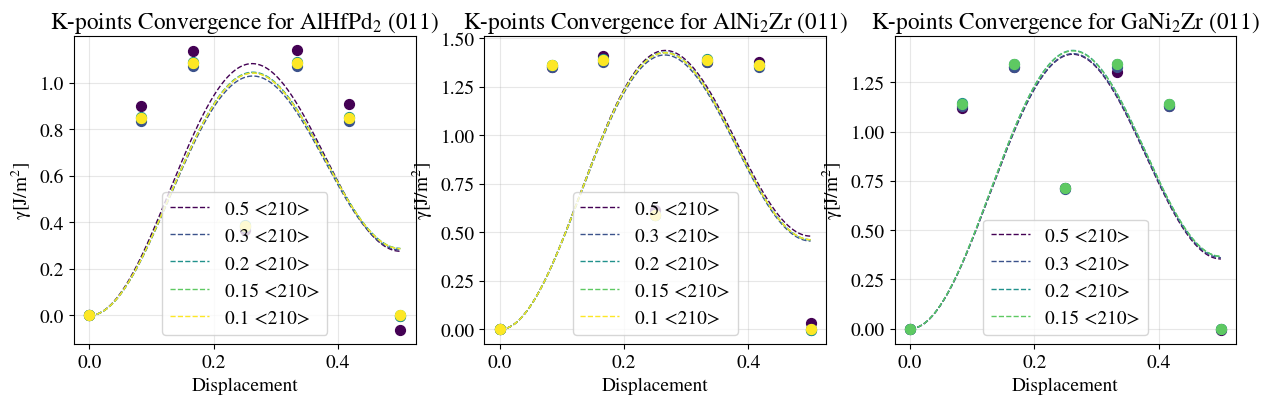

In [13]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 3, figsize=(5 * 3, 4), squeeze=False)

kconv_results = {}

kconv_results['AlHfPd2'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='L2_1',
    formula='AlHfPd2',
    gliding_plane='011',
    directions=['210',],
    n_repeats=4,
    ax=axs[0, 0],
    fit=True,
    order=2)
kconv_results['AlNi2Zr'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='L2_1',
    formula='AlNi2Zr',
    gliding_plane='011',
    directions=['210',],
    n_repeats=4,
    ax=axs[0, 1],
    fit=True,
    order=2)
kconv_results['GaNi2Zr'] = gsfe_groups.plot_kpoints_convergence(
    structure_type='L2_1',
    formula='GaNi2Zr',
    gliding_plane='011',
    directions=['210',],
    n_repeats=4,
    ax=axs[0, 2],
    fit=True,
    order=2)

#### supercell convergence

In [1]:
for material in ['ZrGaNi2']:
    for n_repeats in [2, 3, 4, 5]:
        structure = read_structure_from_file(material)
        builder = GSFEWorkChain.get_builder_from_protocol(
            code=code,
            structure=structure,
            # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
            protocol='fast',
            overrides=v1_overrides,
            n_repeats=n_repeats,
            gliding_plane='011',
        )
        builder.kpoints_distance = orm.Float(0.3)
        builder.clean_workdir = orm.Bool(False)
        logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
        logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
        logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
        node = engine.submit(builder)
        # result, node = engine.run_get_node(builder)
        ductility_grp.add_nodes([node])

NameError: name 'read_structure_from_file' is not defined

In [4]:
gsfe_groups = dislocation.GSFEGroupDataLatest(
    groups = ['gsfe/L21/conv/n_repeats']
)

In [5]:
gsfe_groups.get_table()

Plane                                 011
Structure Material Layers K_Dist         
L2_1      AlHfPd2  2      0.3     ✅ 81447
                   3      0.3     ✅ 81466
                   4      0.3     ✅ 81486
                   5      0.3     ✅ 81508
          AlNi2Zr  2      0.3     ✅ 81555
                   3      0.3     ✅ 81574
                   4      0.3     ✅ 81594
                   5      0.3     ✅ 81615
          GaNi2Zr  2      0.3     ✅ 81645
                   3      0.3     ✅ 81667
                   4      0.3     ✅ 81689
                   5      0.3     ✅ 81711

<Axes: title={'center': 'Supercell Convergence for $GaNi_{2}Zr$ (011)'}, xlabel='Displacement', ylabel='$\\gamma [J/m^2]$'>

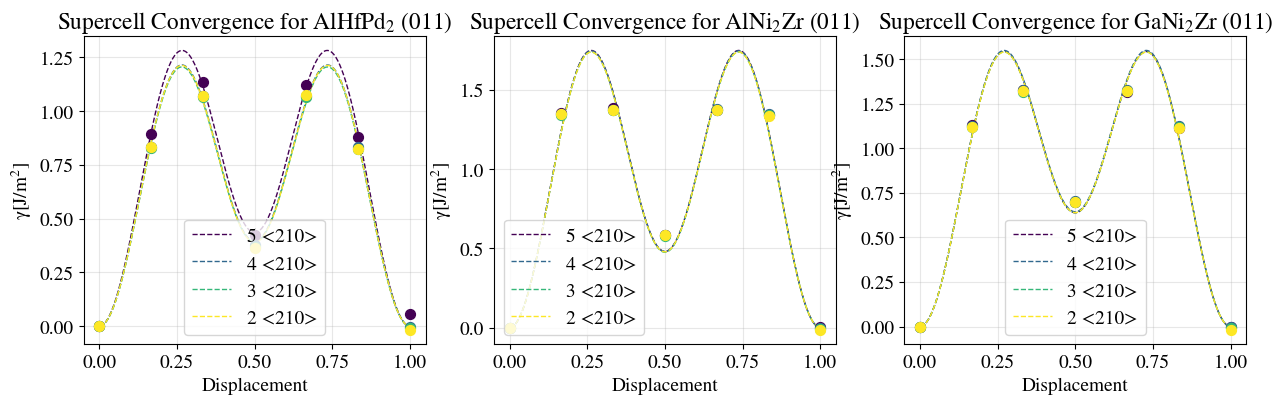

In [9]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.default'] = 'regular'
fig, axs = plt.subplots(1, 3, figsize=(5 * 3, 4), squeeze=False)

supercell_results = {}
gsfe_groups.plot_supercell_convergence(
    structure_type='L2_1',
    formula='AlHfPd2',
    gliding_plane='011',
    directions=['210',],
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.3,
    ax = axs[0, 0],
    fit=True,
)
gsfe_groups.plot_supercell_convergence(
    structure_type='L2_1',
    formula='AlNi2Zr',
    gliding_plane='011',
    directions=['210',],
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.3,
    ax = axs[0, 1],
    fit=True,
)
gsfe_groups.plot_supercell_convergence(
    structure_type='L2_1',
    formula='GaNi2Zr',
    directions=['210',],
    gliding_plane='011',
    # directions=['010',],
    # kpoints_distances=[0.5, 0.3, 0.2],
    kpoints_distances=0.3,
    ax = axs[0, 2],
    fit=True,
)

#### gsfe submission

In [3]:
ductility_grpname = f'gsfe/L21/vc-relax/more_steps'
ductility_grp, _ = orm.Group.collection.get_or_create(ductility_grpname)

code, v1_overrides = load_codes(
    version = 'q-e-qe-7.5',
    computer_label = 'lumi_async',
    overrides_path = '/home/yimzhang/Development/aiida/ductility/code/dislocations/sfe_lumi.yaml',
    )

In [4]:
import logging

v1_overrides['sfe'] = v1_overrides['sfe_relax']
# for material in ['YSnPd2', 'ZrAlNi2', 'ZrGaNi2',]:
for material in ['HfAlPd2', 'YSnPd2']:
    structure = read_structure_from_file(material)
    builder = GSFERelaxWorkChain.get_builder_from_protocol(
        code=code,
        structure=structure,
        # structure=strucctures_classified_by_strukturbericht['A1']['Pb'],
        protocol='fast',
        overrides=v1_overrides,
        n_repeats = orm.Int(3),
        gliding_plane = orm.Str('011')
    )
    builder.kpoints_distance = orm.Float(0.3)
    builder.clean_workdir = orm.Bool(False)

    # builder.layer_spacings = orm.List([0.000, 0.002, 0.006, 0.012, 0.02, 0.036])
    # builder.pop('relax')
    # builder.pop('scf')
    # builder.pop('surface_energy')
    logging.getLogger('aiida.transport.SshTransport').setLevel(logging.ERROR)
    logging.getLogger('aiida.scheduler.slurm').setLevel(logging.ERROR)
    logging.getLogger('aiida.broker.rabbitmq').setLevel(logging.ERROR)
    node = engine.submit(builder)
    # result, node = engine.run_get_node(builder)
    ductility_grp.add_nodes([node])

/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: pseudo_family
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: vacuum_ratio
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_spacings
  warnings.warn(f'Found unrecognised key in overrides: {full_key}')
/home/yimzhang/Development/aiida/packages/aiida-quantumespresso/src/aiida_quantumespresso/workflows/protocols/utils.py:147: UserWarning: Found unrecognised key in overrides: layer_relax
  warnings.warn(f'Found unrecognised key in ov

#### gsfe submission

In [3]:
gsfe_groups = dislocation.GSFERelaxGroupData(
    groups = ['gsfe/L21/vc-relax/more_steps']
)

In [4]:
gsfe_groups.get_table()

Plane                                                                                    011
Structure Material Process            Layers K_Dist Conv_thr                                
L2_1      AlHfPd2  GSFERelaxWorkChain 3      0.3    5.0e-07 Ry (+- 2.7e-04 mJ/m^2)  ✅ 121928
          Pd2SnY   GSFERelaxWorkChain 3      0.3    5.0e-07 Ry (+- 2.5e-04 mJ/m^2)  ✅ 121951

{'100': {'usf': np.float64(0.8904885543473156),
  's': np.float64(0.005528953314888563)},
 '210': {'usf': np.float64(0.7567020604992876),
  's': np.float64(0.4498462083180711)},
 '010': {'usf': np.float64(0.5727139704636875),
  's': np.float64(0.2711242532659893)}}

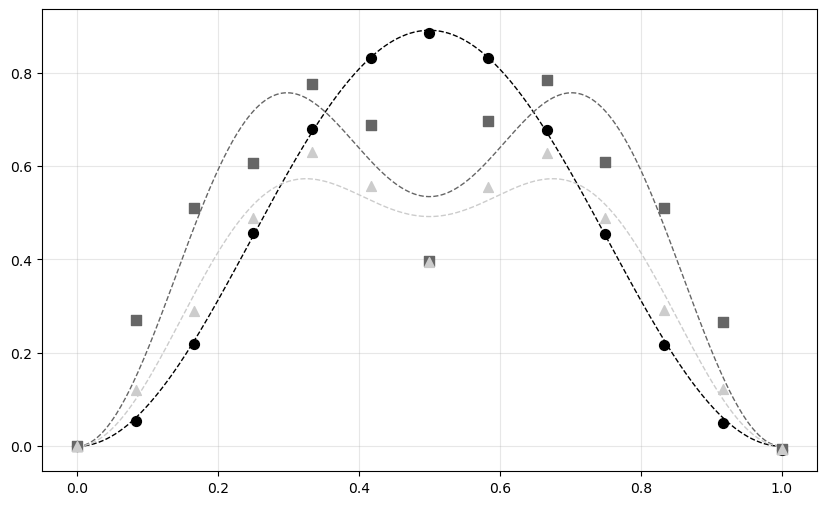

In [5]:
analyser =  GSFERelaxWorkChainAnalyser(orm.load_node(121951))
analyser.fit_curve(plot=True)

In [6]:
gsfe_groups._data['L2_1'].pop('GaNi2Zr', None)
gsfe_groups._data['L2_1'].pop('AlNi2Zr', None)
gsfe_groups._data['L2_1'].pop('AlHfPd2', None)

# gsfe_groups._data['L2_1'].pop('Pd2SnY', None)
# gsfe_groups._data['L2_1']['AlHfPd2']['011']['GSFEWorkChain'][3].pop(0.15, None)
# gsfe_groups._data['L2_1']['AlHfPd2'].pop('100', None)


defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
            {'011': defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                         {'GSFERelaxWorkChain': defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                      {3: defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                                   {0.3: defaultdict(<function aiida_analyser.dislocation.gsfe_relax.GSFERelaxGroupData.__init__.<locals>.<lambda>.<locals>.<lambda>.<locals>.<lambda>

In [7]:
surface_energy_results = gsfe_groups.get_surface_energies()

AttributeError: 'GSFERelaxGroupData' object has no attribute 'get_surface_energies'

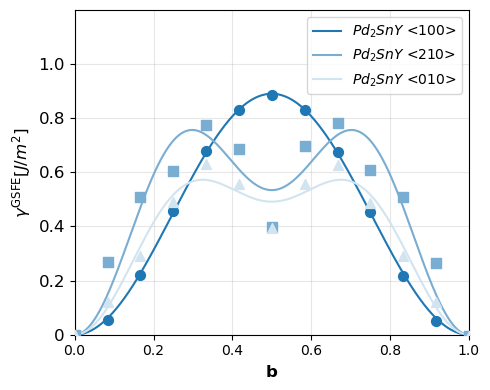

In [8]:
import matplotlib.pyplot as plt
import numpy

fig, axs = plt.subplots(1, 1, figsize=(5, 4), squeeze=False)
results = gsfe_groups.fit(axs=axs, order=3)
axs[0, 0].set_title('')
axs[0, 0].set_xlabel('')
axs[0, 0].set_xlim([0, 1])
# axs[0, 0].set_xticks([])
# axs[0, 0].set_xticklabels([])
axs[0, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axs[0, 0].set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=12)
axs[0, 0].legend(loc='upper right', fontsize=10)
axs[0, 0].set_ylabel(r'$\gamma^{\rm GSFE} [J/m^2]$', fontsize=12)
# axs[1, 0].legend(loc='upper right', fontsize=10)
# axs[0, 1].set_xlim([0, 1])
# axs[0, 1].set_yticks([0, 1, 2, 3])
# axs[0, 1].set_yticklabels([0, 1, 2, 3], fontsize=12)
# axs[0, 1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
# axs[0, 1].set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=12)
# axs[0, 1].set_ylabel(r'$\gamma [J/m^2]$', fontsize=12)
# axs[0, 1].set_ylabel('')
# axs[0, 1].set_xlabel('')
# axs[0, 1].set_xticklabels([])
axs[0, 0].set_ylim([0, 1.2])
# axs[0, 1].set_xlim([0, 1])
# axs[0, 1].set_ylim([0, 3])
# axs[0, 1].set_yticks([0, 0.5, 1, 1.5, 2])
# axs[0, 1].set_yticklabels([0, 0.5, 1, 1.5, 2], fontsize=12)
axs[0, 0].set_xlabel(r'$\mathbf{b}$', fontsize=12)
# axs[0, 1].set_xlabel(r'$\vec{b}$', fontsize=12) 
# axs[0, 1].get_legend().remove()
fig.tight_layout()
fig.savefig('/home/yimzhang/Development/aiida/ductility/data/dislocation/fig3.pdf', dpi=300,bbox_inches='tight', pad_inches=0)

In [8]:
results

{'L2_1': {'011': {'AlHfPd2': {'210': {'usf': np.float64(1.0613409786694823),
     's': np.float64(0.6790740097943874)},
    '100': {'usf': np.float64(1.68614413935583),
     's': np.float64(0.5720848039066211)},
    '010': {'usf': np.float64(3.743978430558519),
     's': np.float64(3.400505598666815)}},
   'Pd2SnY': {'210': {'usf': np.float64(1.0794005411288219),
     's': np.float64(0.7219190785828887)},
    '100': {'usf': np.float64(1.3714616469492729),
     's': np.float64(0.6450776396736186)},
    '010': {'usf': np.float64(3.0088329356064345),
     's': np.float64(2.743101565473737)}}}}}

In [29]:
import pandas as pd
import numpy as np
from pymatgen.core import Composition

def format_cell(calc_val, literature, is_surface=False):
    """
    处理单元格，将计算值与文献元组列表合并
    """
    contents = []
    
    # 1. 处理本代码计算得到的数值
    if calc_val is not None and str(calc_val) != '-':
        # 按照原逻辑，表面能不乘1000，其余乘
        real_val = float(calc_val) * 1000 if not is_surface else float(calc_val)
        contents.append(f"{real_val:.2f}")
    elif not literature:
        # 如果计算值为空且文献也为空，返回横杠
        return "-"

    # 2. 处理文献元组列表 [(数值, 标签), ...]
    if literature:
        for val, cite_key in literature:
            # 生成类似 "97 \cite{Tu2019}" 或 "21$\pm$7 \cite{Dillamore1965}"
            entry_str = f"{val} \\cite{{{cite_key}}}"
            contents.append(entry_str)
        
    # 3. 用 \newline 连接所有项
    return " \\newline ".join(contents)

headers = [
    "Material",
    r"$\gamma^{\rm USEF}_{011}$",
    r"$\gamma^{\rm USFE}_{100}$",
    # r"$\gamma^{\rm surface}_{100}$",
    r"$\gamma^{\rm surface}_{011}$",
    r"$\text{Rice ratio}_{011}$",
    r"$\frac{G}{B}$"]
data = []
elements = sorted(list(results['L2_1']['011'].keys())) 
print(elements)
for elem in elements:
    row = [
        elem,  # Material
        format_cell(kconv_results[elem][1][0.2]['210']['usf'], literature=None),
        format_cell(results['L2_1']['100'][elem]['110']['usf'],literature=None),
        # format_cell(surface_energy_results['C1b']['100'][elem]['surface_energy']*1000, literature=None, is_surface=True),
        format_cell(surface_energy_results['L2_1']['011'][elem]['surface_energy']*1000, literature=None, is_surface=True),
        format_cell(kconv_results[elem][1][0.2]['210']['usf'] / (surface_energy_results['L2_1']['011'][elem]['surface_energy']*1000), literature=None),
        "-",
    ]
    data.append(row)
    
df = pd.DataFrame(data=data, columns=headers)
latex_output = df.style.hide(axis="index").to_latex(
    caption="Generalized stacking fault energy and surface energies.",
    label="tab:table2",
    environment="table*",
    position="htbp",
    hrules=True
)
print(latex_output)


['AlHfPd2', 'AlNi2Zr', 'GaNi2Zr']
\begin{table*}[htbp]
\caption{Generalized stacking fault energy and surface energies.}
\label{tab:table2}
\begin{tabular}{llllll}
\toprule
Material & $\gamma^{\rm USEF}_{011}$ & $\gamma^{\rm USFE}_{100}$ & $\gamma^{\rm surface}_{011}$ & $\text{Rice ratio}_{011}$ & $\frac{G}{B}$ \\
\midrule
AlHfPd2 & 1237.62 & 2426.85 & 1544.78 & 0.80 & - \\
AlNi2Zr & 1765.42 & 2541.54 & 1783.12 & 0.99 & - \\
GaNi2Zr & 1569.39 & 2494.17 & 1654.50 & 0.95 & - \\
\bottomrule
\end{tabular}
\end{table*}

